# Autism Risk Screening — Southern Africa (Lesotho)
### Multimodal AI Pipeline

**Pipeline sections:**
1. Imports & setup
2. Data loading & preprocessing
3. Exploratory data analysis
4. Model training (behavioural + demographic XGBoost)
5. Late fusion & evaluation
6. DHS threshold recalibration
7. **Comorbidity adjustment — population-level sensitivity sweep**
8. **Comorbidity adjustment — individual-level layer (simulated DHS-linked status)**
9. SHAP explainability
10. Cultural alignment / item-level perturbation analysis (robustness contribution)
11. Subgroup fairness evaluation
12. Save models

> Research prototype — not for clinical use.

# Install dependencies

In [5]:

 !pip install xgboost shap librosa imbalanced-learn pyreadstat openpyxl seaborn --quiet


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Library Imports

In [6]:
import os, warnings
from pathlib import Path
import traceback

warnings.filterwarnings("ignore")

import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings
warnings.filterwarnings("ignore")
print(sys.executable)

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, learning_curve
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import xgboost as xgb

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    shap = None
    SHAP_AVAILABLE = False
    SHAP_IMPORT_ERROR = traceback.format_exc()
    print(f"SHAP unavailable; explainability steps will be skipped. ({exc.__class__.__name__}: {exc})")

import joblib

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / "data" / "raw" / "qchat" / "Autusim_DATA_Clean_Encoded.xlsx").exists():
        PROJECT_ROOT = candidate
        break

os.chdir(PROJECT_ROOT)
os.makedirs("outputs/evaluation", exist_ok=True)
os.makedirs("outputs/fairness",   exist_ok=True)
os.makedirs("outputs/alignment",  exist_ok=True)
os.makedirs("models",             exist_ok=True)

print("Imports OK  |  XGBoost", xgb.__version__)
print(f"Project root: {PROJECT_ROOT}")

c:\Users\PC\Autism-Risk-Screening\.venv\Scripts\python.exe
Imports OK  |  XGBoost 3.2.0
Project root: c:\Users\PC\Autism-Risk-Screening


---
# Data Loading & Preprocessing

**Training data:** Unified Q-CHAT-10 toddler dataset (Abbadi & Thabtah, 2025)  
Filtered to ages 18–36 months (1.5–3.0 years) → 1,601 records

**Test data:** Polish clinical dataset (Niedźwiecka et al., 2020)  
Q-CHAT-25 format — items QCHAT1RE–QCHAT10R used  
Loaded via pyreadstat from `data/raw/qchat/QCHAT_dataset2_mendeley.sav`

In [7]:
import os
os.chdir(r"C:\Users\PC\Autism-Risk-Screening")
print("Now working in:", os.getcwd())

Now working in: C:\Users\PC\Autism-Risk-Screening


In [8]:
# Load Q-CHAT dataset
df_raw = pd.read_excel("data/raw/qchat/Autusim_DATA_Clean_Encoded.xlsx")
# Keep only toddlers aged 18–36 months
df = df_raw[
    (df_raw["Age"] >= 1.5) &
    (df_raw["Age"] <= 3.0)
].copy()

# Rename columns to match the training pipeline
df = df.rename(columns={
    "a1": "q1",
    "a2": "q2",
    "a3": "q3",
    "a4": "q4",
    "a5": "q5",
    "a6": "q6",
    "a7": "q7",
    "a8": "q8",
    "a9": "q9",
    "a10": "q10",
    "Age": "age_years",
    "Gender": "sex",
    "Class": "label"
})

# Remove any age values outside the target range
df = df[df["age_years"] <= 3.0]

print(f"Training dataset: {len(df)} rows")

print(
    f"Age range: "
    f"{df['age_years'].min():.2f}–{df['age_years'].max():.2f} years "
    f"({df['age_years'].min()*12:.0f}–{df['age_years'].max()*12:.0f} months)"
)

print(f"Class distribution: {df['label'].value_counts().to_dict()}")

print(
    f"Sex distribution: {df['sex'].value_counts().to_dict()} "
    f"(0 = Female, 1 = Male)"
)

df.head()

Training dataset: 1601 rows
Age range: 1.50–3.00 years (18–36 months)
Class distribution: {0: 929, 1: 672}
Sex distribution: {1: 1154, 0: 447} (0 = Female, 1 = Male)


,id,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,age_years,sex,Ethnicity,Jaundice,Family_ASD,label,Who_Completed,Qchat_Score
0,1,0,0,0,0,0,0,1,1,0,1,2.333333,0,0,0,0,0,family member,3
1,2,1,1,0,0,0,1,1,0,0,0,3.000000,1,1,0,0,1,family member,4
2,3,1,0,0,0,0,0,1,1,0,1,3.000000,1,0,0,0,1,family member,4
3,4,1,1,1,1,1,1,1,1,1,1,2.000000,1,2,1,0,1,family member,10
4,5,1,1,0,1,1,1,1,1,1,1,1.666667,0,1,1,1,1,family member,9


In [9]:
# Load Polish clinical test set (Q-CHAT-25, items 1–10 used)
# FIX: binarise Likert-scale responses with Q10 reversal; correct label encoding

try:
    import pyreadstat
    df_test_raw, meta = pyreadstat.read_sav("data/raw/qchat/QCHAT_dataset2 mendeley.sav")

    # Binarise Q-CHAT items 1–10 per Allison et al. (2008):
    # Items Q1–Q9: atypical = score >= 2 (Sometimes, Rarely, Never)
    # Item  Q10:   reversed — atypical = score <= 2 (Always, Usually, Sometimes)
    for i in range(1, 11):
        col = f"qchat{i}recode"
        raw = pd.to_numeric(df_test_raw[col], errors="coerce")
        if i == 10:
            df_test_raw[f"q{i}"] = (raw <= 2).astype(float)   # reversed item
        else:
            df_test_raw[f"q{i}"] = (raw >= 2).astype(float)

    # Labels: group=1.0 → ASD (label=1), group=7.0 → control (label=0)
    df_test_raw["label"] = (
        pd.to_numeric(df_test_raw["group"], errors="coerce") == 1.0
    ).astype(int)

    # Sex: 1.0=Male → 1, 2.0=Female → 0
    df_test_raw["sex"] = (
        pd.to_numeric(df_test_raw["sex"], errors="coerce") == 1.0
    ).astype(int)

    # Age is in months — convert to years
    df_test_raw["age_years"] = pd.to_numeric(df_test_raw["age"], errors="coerce") / 12.0

    # Jaundice and Family_ASD not collected in Polish dataset — set to 0
    df_test_raw["Jaundice"]   = 0
    df_test_raw["Family_ASD"] = 0

    # Filter to 18–36 months (1.5–3.0 years)
    df_test = df_test_raw[
        (df_test_raw["age_years"] >= 1.5) &
        (df_test_raw["age_years"] <= 3.0)
    ].copy()

    required_cols = (
        [f"q{i}" for i in range(1, 11)]
        + ["age_years", "sex", "label", "Jaundice", "Family_ASD"]
    )
    df_test = df_test.dropna(subset=required_cols)

    print(f"Polish test set: {len(df_test)} rows")
    print(f"Age range: {df_test['age_years'].min():.2f}–{df_test['age_years'].max():.2f} years")
    print(f"Class distribution: {df_test['label'].value_counts().to_dict()}")
    print(f"Sex distribution:   {df_test['sex'].value_counts().to_dict()}")
    print(f"Q10 value check (should differ from Q1): "
          f"Q1 mean={df_test['q1'].mean():.3f}  Q10 mean={df_test['q10'].mean():.3f}")

    # Verify group encoding via meta labels
    grp_labels = meta.variable_value_labels.get("group", {})
    print(f"Group labels from file: {grp_labels}")
    group_num = pd.to_numeric(df_test_raw["group"], errors="coerce")
    print(f"ASD (group==1): {(group_num==1).sum()}  Control (group==7): {(group_num==7).sum()}")

    USE_POLISH_TEST = len(df_test) >= 20

except Exception as e:
    print(f"Polish test set failed to load: {e}")
    USE_POLISH_TEST = False
    df_test = None


Polish test set: 252 rows
Age range: 1.50–2.00 years
Class distribution: {1: 135, 0: 117}
Sex distribution:   {1: 157, 0: 95}
Q10 value check (should differ from Q1): Q1 mean=0.313  Q10 mean=0.794
Group labels from file: {1.0: 'ASD', 7.0: 'control'}
ASD (group==1): 135  Control (group==7): 117


In [10]:
# Feature definitions

QCHAT_COLS = [f"q{i}" for i in range(1, 11)]
DEM_COLS = ["age_years", "sex", "Jaundice", "Family_ASD"]



# Train / test split (polish dataset vs internal split)


if USE_POLISH_TEST:
    # External test set (fixed evaluation set)
    X_beh_train = df[QCHAT_COLS].values.astype(float)
    X_dem_train = df[DEM_COLS].values.astype(float)
    y_train = df["label"].values.astype(int)

    X_beh_test = df_test[QCHAT_COLS].values.astype(float)
    X_dem_test = df_test[DEM_COLS].values.astype(float)
    y_test = df_test["label"].values.astype(int)

    df_test_ref = df_test.reset_index(drop=True)

else:
    # Internal stratified split
    X_beh_all = df[QCHAT_COLS].values.astype(float)
    X_dem_all = df[DEM_COLS].values.astype(float)
    y_all = df["label"].values.astype(int)

    idx = np.arange(len(df))

    idx_train, idx_test = train_test_split(
        idx,
        test_size=0.2,
        stratify=y_all,
        random_state=SEED
    )

    X_beh_train, X_beh_test, y_train, y_test = train_test_split(
        X_beh_all,
        y_all,
        test_size=0.2,
        stratify=y_all,
        random_state=SEED
    )

    X_dem_train = X_dem_all[idx_train]
    X_dem_test = X_dem_all[idx_test]

    df_test_ref = df.iloc[idx_test].reset_index(drop=True)



# Quick dataset sanity check

print(f"Train samples: {len(y_train)} | Test samples: {len(y_test)}")

train_dist = dict(zip(*np.unique(y_train, return_counts=True)))
test_dist = dict(zip(*np.unique(y_test, return_counts=True)))

print(f"Train class distribution: {train_dist}")
print(f"Test class distribution:  {test_dist}")

print(f"Demographic features used: {DEM_COLS}")

Train samples: 1601 | Test samples: 252
Train class distribution: {np.int64(0): np.int64(929), np.int64(1): np.int64(672)}
Test class distribution:  {np.int64(0): np.int64(117), np.int64(1): np.int64(135)}
Demographic features used: ['age_years', 'sex', 'Jaundice', 'Family_ASD']


---
# Exploratory Data Analysis




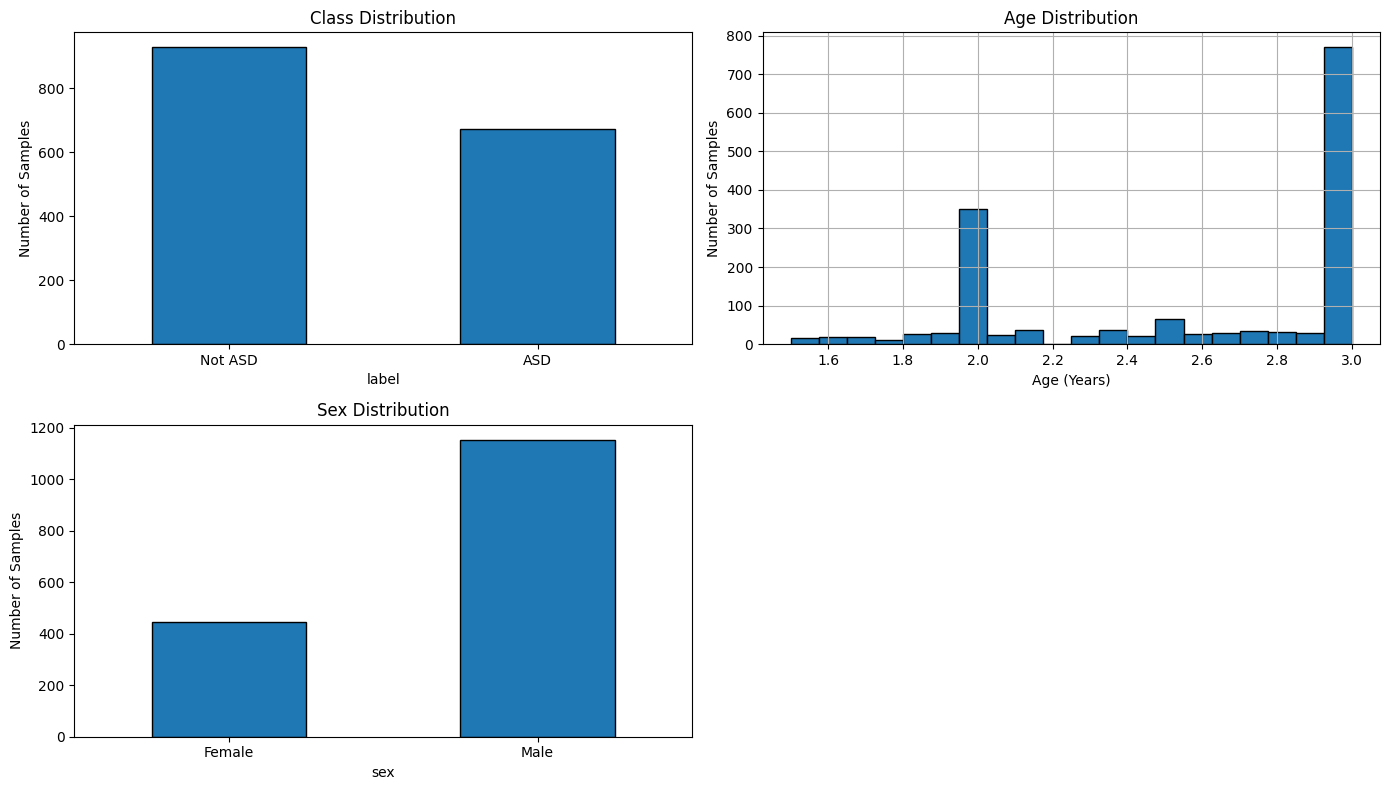


=== Training Dataset Summary ===
Samples: 1601
Class distribution: {0: 929, 1: 672}
Sex distribution: {1: 1154, 0: 447}
Age range: 1.50–3.00 years


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Class distribution
df["label"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0, 0],
    edgecolor="black"
)
axes[0, 0].set_xticklabels(["Not ASD", "ASD"], rotation=0)
axes[0, 0].set_title("Class Distribution")
axes[0, 0].set_ylabel("Number of Samples")

# Age distribution
df["age_years"].hist(
    bins=20,
    ax=axes[0, 1],
    edgecolor="black"
)
axes[0, 1].set_title("Age Distribution")
axes[0, 1].set_xlabel("Age (Years)")
axes[0, 1].set_ylabel("Number of Samples")

# Sex distribution
df["sex"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1, 0],
    edgecolor="black"
)
axes[1, 0].set_xticklabels(["Female", "Male"], rotation=0)
axes[1, 0].set_title("Sex Distribution")
axes[1, 0].set_ylabel("Number of Samples")

# Training source distribution (NZ + Saudi only)
if "source" in df.columns:
    df["source"].value_counts().plot(
        kind="bar",
        ax=axes[1, 1],
        edgecolor="black"
    )
    axes[1, 1].set_title("Training Dataset Sources")
    axes[1, 1].set_xlabel("Source")
    axes[1, 1].set_ylabel("Number of Samples")
    axes[1, 1].tick_params(axis="x", rotation=0)
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig(
    "outputs/evaluation/eda_overview.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Summary statistics
print("\n=== Training Dataset Summary ===")
print(f"Samples: {len(df)}")
print(f"Class distribution: {df['label'].value_counts().to_dict()}")
print(f"Sex distribution: {df['sex'].value_counts().to_dict()}")
print(f"Age range: {df['age_years'].min():.2f}–{df['age_years'].max():.2f} years")

if "source" in df.columns:
    print(f"Source distribution: {df['source'].value_counts().to_dict()}")

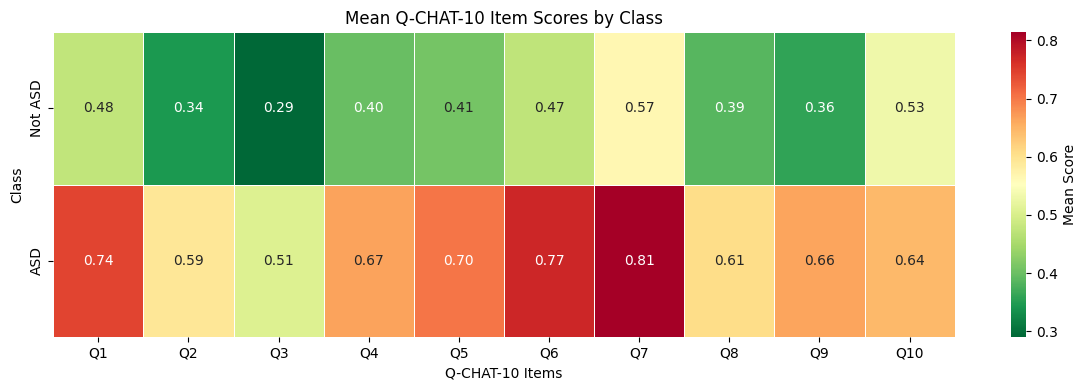

In [13]:
# Mean Q-CHAT-10 item scores by autism class
item_means = df.groupby("label")[QCHAT_COLS].mean()

fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(
    item_means,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "Mean Score"},
    xticklabels=[f"Q{i}" for i in range(1, 11)],
    yticklabels=["Not ASD", "ASD"],
    ax=ax
)

ax.set_title("Mean Q-CHAT-10 Item Scores by Class")
ax.set_xlabel("Q-CHAT-10 Items")
ax.set_ylabel("Class")

plt.tight_layout()
plt.savefig(
    "outputs/evaluation/qchat_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

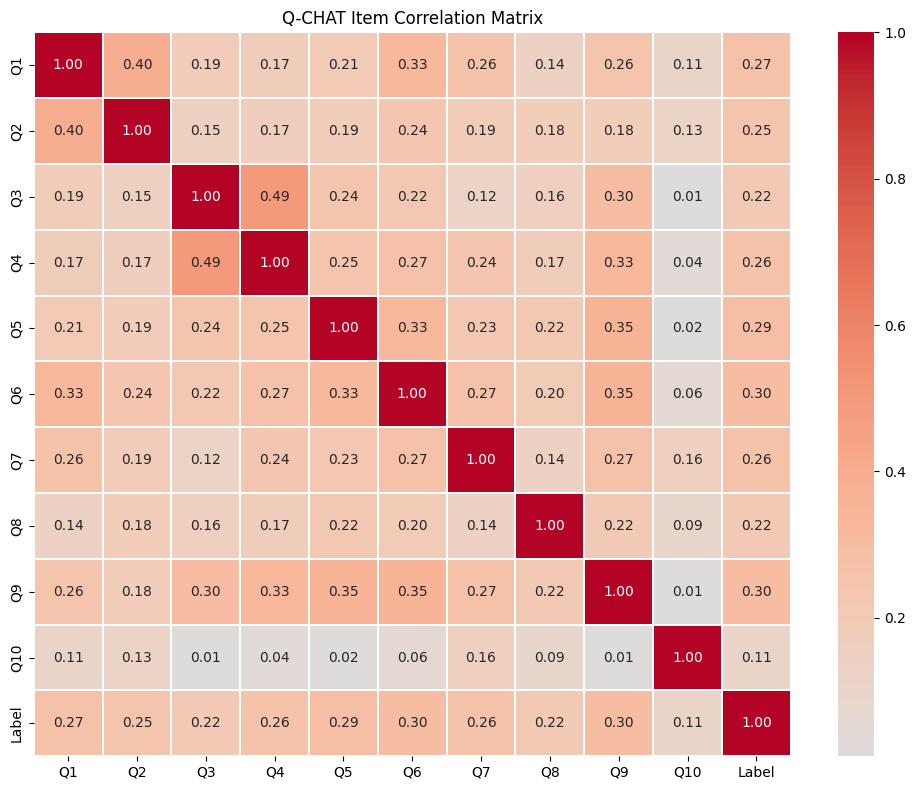

In [12]:
# Q-CHAT correlation matrix 

import matplotlib.pyplot as plt

cols = QCHAT_COLS + ["label"]

corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    xticklabels=[f"Q{i}" for i in range(1, 11)] + ["Label"],
    yticklabels=[f"Q{i}" for i in range(1, 11)] + ["Label"],
    linewidths=0.3
)

ax.set_title("Q-CHAT Item Correlation Matrix")
plt.tight_layout()

os.makedirs("outputs/evaluation", exist_ok=True)
plt.savefig("outputs/evaluation/correlation_matrix.png", dpi=150)

plt.show()

---
##  Model Training

In [13]:
from sklearn.model_selection import RandomizedSearchCV

# Apply SMOTE to balance the behavioural training data
smote = SMOTE(random_state=SEED)
X_beh_res, y_beh_res = smote.fit_resample(X_beh_train, y_train)

# Define the hyperparameter search space
beh_param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
}

# Create the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Search for the best hyperparameter combination
beh_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        eval_metric="logloss",
        random_state=SEED,
        verbosity=0,
    ),
    param_distributions=beh_param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
)

beh_search.fit(X_beh_res, y_beh_res)

# Display the best cross-validation performance
print(f"Behavioural best CV AUROC: {beh_search.best_score_:.3f}")
print(f"Best parameters: {beh_search.best_params_}")

# Train the final behavioural model using the best parameters
xgb_beh = xgb.XGBClassifier(
    **beh_search.best_params_,
    eval_metric="logloss",
    random_state=SEED,
    verbosity=0,
)

xgb_beh.fit(X_beh_res, y_beh_res)

Behavioural best CV AUROC: 0.779
Best parameters: {'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [15]:
# Train the demographic model using age, sex, jaundice, and family history of ASD

# Apply SMOTE to balance the training data
X_dem_res, y_dem_res = smote.fit_resample(X_dem_train, y_train)

# Define the parameter combinations to test
dem_param_dist = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1, 0.15, 0.2],
    "subsample": [0.7, 0.8, 1.0],
}

# Perform random search to find the best hyperparameters
dem_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        eval_metric="logloss",
        random_state=SEED,
        verbosity=0,
    ),
    param_distributions=dem_param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
)

dem_search.fit(X_dem_res, y_dem_res)

# Display the best cross-validation score and parameters
print(f"Demographic best CV AUROC: {dem_search.best_score_:.3f}")
print(f"Best parameters: {dem_search.best_params_}")

# Train the final model using the best parameters
xgb_dem = xgb.XGBClassifier(
    **dem_search.best_params_,
    eval_metric="logloss",
    random_state=SEED,
    verbosity=0,
)

xgb_dem.fit(X_dem_res, y_dem_res)

Demographic best CV AUROC: 0.746
Best parameters: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05}


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [16]:
from imblearn.pipeline import Pipeline

pipeline_beh = Pipeline([
    ("smote", SMOTE(random_state=SEED)),
    ("model", xgb_beh),
])

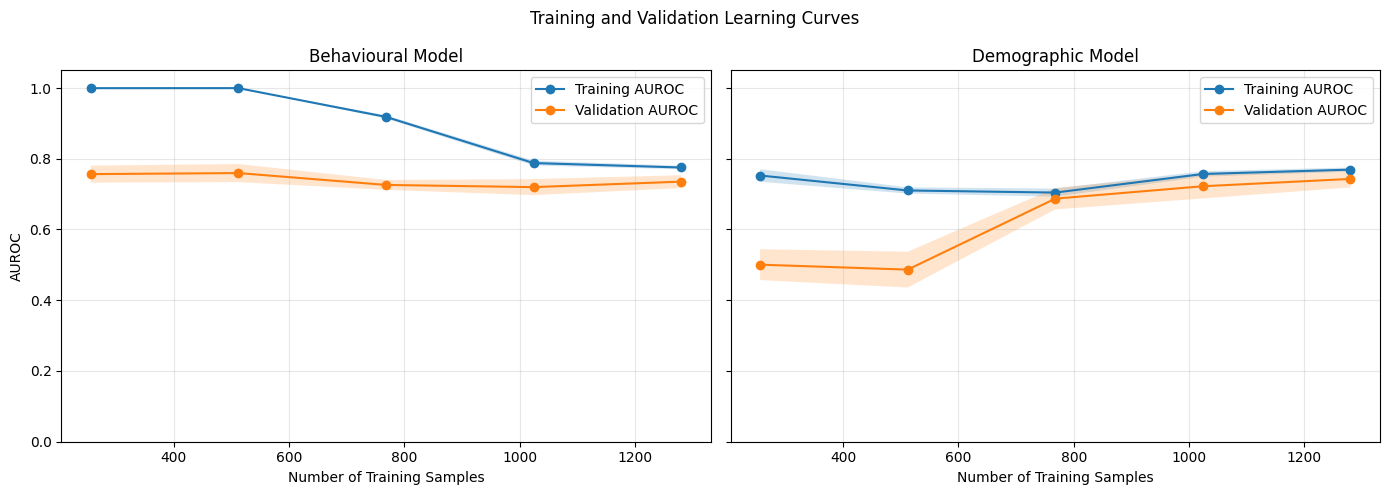

In [17]:
# Plot learning curves for the behavioural and demographic models
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Store each model with its corresponding training data
models = [
    ("Behavioural Model", pipeline_beh, X_beh_train),
    ("Demographic Model", Pipeline([("smote", SMOTE(random_state=SEED)), ("model", xgb_dem)]), X_dem_train),
]

# Generate a learning curve for each model
for ax, (model_name, model, X_train) in zip(axes, models):

    # Compute training and validation scores using different training set sizes
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        train_sizes=np.linspace(0.2, 1.0, 5),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring="roc_auc",
        n_jobs=-1,
    )

    # Calculate the mean and standard deviation of the scores
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    # Plot the average training performance
    ax.plot(train_sizes, train_mean, marker="o", label="Training AUROC")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

    # Plot the average validation performance
    ax.plot(train_sizes, validation_mean, marker="o", label="Validation AUROC")
    ax.fill_between(train_sizes, validation_mean - validation_std, validation_mean + validation_std, alpha=0.2)

    # Format the subplot
    ax.set_title(model_name)
    ax.set_xlabel("Number of Training Samples")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()

# Add a shared y-axis label and overall title
axes[0].set_ylabel("AUROC")
plt.suptitle("Training and Validation Learning Curves")

# Adjust spacing, save the figure, and display it
plt.tight_layout()
plt.savefig("outputs/evaluation/training_validation_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Late Fusion & Evaluation

In [18]:

# Base model predictions

prob_beh_train = xgb_beh.predict_proba(X_beh_train)[:, 1]
prob_dem_train = xgb_dem.predict_proba(X_dem_train)[:, 1]

prob_beh_test = xgb_beh.predict_proba(X_beh_test)[:, 1]
prob_dem_test = xgb_dem.predict_proba(X_dem_test)[:, 1]



# Meta-feature construction

X_meta_train = np.column_stack([prob_beh_train, prob_dem_train])
X_meta_test  = np.column_stack([prob_beh_test, prob_dem_test])


# Meta-model (fusion layer)
meta_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED
)

meta_model.fit(X_meta_train, y_train)



# Final prediction

prob_fuse = meta_model.predict_proba(X_meta_test)[:, 1]

THRESHOLD = 0.5
y_pred = (prob_fuse >= THRESHOLD).astype(int)


# Evaluation

print("=== Stacked Fusion Model (Behavioural + Demographic) ===")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Not ASD", "ASD"]
))

auroc = roc_auc_score(y_test, prob_fuse)
print(f"AUROC: {auroc:.3f}")

=== Stacked Fusion Model (Behavioural + Demographic) ===
              precision    recall  f1-score   support

     Not ASD       0.73      0.72      0.72       117
         ASD       0.76      0.77      0.76       135

    accuracy                           0.75       252
   macro avg       0.74      0.74      0.74       252
weighted avg       0.75      0.75      0.75       252

AUROC: 0.809


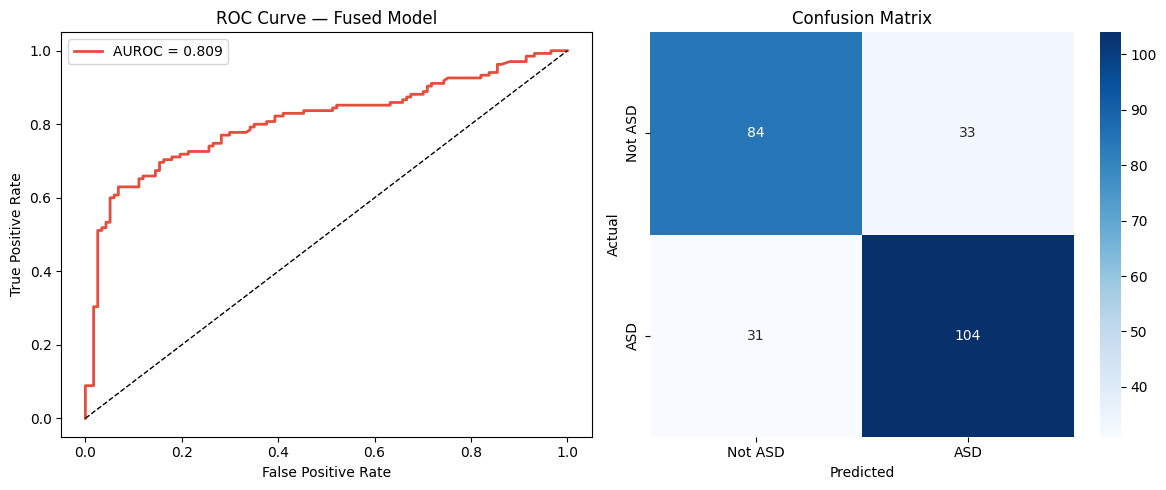

In [19]:
# ROC curve + AUROC

prob_fused = prob_fuse  

fpr, tpr, _ = roc_curve(y_test, prob_fused)
auroc = roc_auc_score(y_test, prob_fused)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color="#e74c3c", lw=2, label=f"AUROC = {auroc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Fused Model")
axes[0].legend()


# Confusion matrix

y_pred = (prob_fused >= THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1],
    xticklabels=["Not ASD", "ASD"],
    yticklabels=["Not ASD", "ASD"]
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix")


# Save + show

plt.tight_layout()
plt.savefig("outputs/evaluation/roc_and_cm.png", dpi=150)
plt.show()

---
# DHS Threshold Recalibration




In [20]:
DHS_CSV_PATH = "data/raw/dhs/LSKR81FL.csv"
DHS_DTA_PATH = "data/raw/dhs/LSKR81FL.DTA"


def compute_dhs_prevalence(df_dhs):
    # Filter to toddlers (18–36 months)
    ages = pd.to_numeric(df_dhs["b19"], errors="coerce")
    df_t = df_dhs[(ages >= 18) & (ages <= 36)].copy()
    print(f"  Toddlers (18–36 months): n = {len(df_t)}")

    # Stunting: HAZ < -2 SD (remove DHS missing codes)
    hw70 = pd.to_numeric(df_t["hw70"], errors="coerce")
    hw70 = hw70[hw70 < 9000]
    stunting = float(np.nanmean(hw70 < -200))

    # Anaemia: any level (mild, moderate, severe)
    hw57 = pd.to_numeric(df_t["hw57"], errors="coerce")
    anaemia = float(np.nanmean(hw57.isin([1, 2, 3])))

    # Not living with mother (coded as 4)
    b9 = pd.to_numeric(df_t["b9"], errors="coerce")
    no_caregiver = float(np.nanmean(b9 == 4))

    # Rural residence (coded as 2 in DHS)
    v025 = pd.to_numeric(df_t["v025"], errors="coerce")
    rural = float(np.nanmean(v025 == 2))

    return {
        "stunting": stunting,
        "anaemia": anaemia,
        "no_caregiver": no_caregiver,
        "rural": rural,
    }


try:
    # Load DHS dataset (CSV preferred, fallback to .DTA)
    if os.path.exists(DHS_CSV_PATH):
        df_dhs = pd.read_csv(DHS_CSV_PATH, low_memory=False)
        print("DHS loaded from CSV.")
    else:
        df_dhs = pd.read_stata(DHS_DTA_PATH, convert_categoricals=False)
        print("DHS loaded from .DTA.")

    # Compute prevalence estimates
    LESOTHO_DHS_PREVALENCE = compute_dhs_prevalence(df_dhs)

except Exception as e:
    # Fallback values from DHS 2023–24 toddler subset (n=795)
    print(f"DHS file not loaded: {e}")
    print("Using fallback values from DHS 2023–24 toddler subset.")

    LESOTHO_DHS_PREVALENCE = {
        "stunting": 0.5014,
        "anaemia": 0.2755,
        "no_caregiver": 0.0868,
        "rural": 0.7132,
    }

print("\nDHS prevalence estimates (18–36 months)")
for k, v in LESOTHO_DHS_PREVALENCE.items():
    print(f"  {k:15s}: {v:.4f}  ({v*100:.1f}%)")


def recalibrate_threshold(base_threshold, stunting, anaemia, no_caregiver, rural):
    # Combine DHS indicators into a single population risk score
    risk_score = (
        0.4 * stunting +
        0.3 * anaemia +
        0.2 * no_caregiver +
        0.1 * rural
    )

    # Adjust threshold based on population-level risk shift
    # compared to training baseline (0.35)
    adjustment = (risk_score - 0.35) * 0.25

    return float(np.clip(base_threshold - adjustment, 0.35, 0.65))


CALIBRATED_THRESHOLD = recalibrate_threshold(
    THRESHOLD,
    **LESOTHO_DHS_PREVALENCE
)

print(f"\nDefault threshold:    {THRESHOLD:.4f}")
print(f"Calibrated threshold: {CALIBRATED_THRESHOLD:.4f}")
print(
    f"Shift:                {THRESHOLD - CALIBRATED_THRESHOLD:+.4f} "
    f"({'more sensitive' if CALIBRATED_THRESHOLD < THRESHOLD else 'less sensitive'})"
)

DHS loaded from CSV.
  Toddlers (18–36 months): n = 795

DHS prevalence estimates (18–36 months)
  stunting       : 0.5014  (50.1%)
  anaemia        : 0.2755  (27.5%)
  no_caregiver   : 0.0868  (8.7%)
  rural          : 0.7132  (71.3%)

Default threshold:    0.5000
Calibrated threshold: 0.4945
Shift:                +0.0055 (more sensitive)


---
##  Enriched DHS Calibration
Extends calibration with 6 additional developmental risk indicators from the Births Recode (LSBR81FL).

In [21]:
# 5b uses the Births Recode (LSBR81FL) dataset
# Includes: b11 (birth interval), m14 (ANC visits), m15 (delivery place),
# m18 (birth size), v106 (maternal education), v190 (wealth index)

DHS_BR_CSV = "data/raw/dhs/LSBR81FL.csv"
DHS_BR_DTA = "data/raw/dhs/LSBR81FL.DTA"

try:
    # Load dataset (CSV preferred, fallback to Stata file)
    if os.path.exists(DHS_BR_CSV):
        df_br = pd.read_csv(DHS_BR_CSV, low_memory=False)

        # Rename columns if using a slim/exported version
        if "age_months" in df_br.columns:
            df_br = df_br.rename(columns={
                "age_months": "b19",
                "birth_interval": "b11",
                "antenatal_visits": "m14",
                "place_delivery": "m15",
                "birth_size": "m18",
                "mother_education": "v106",
                "wealth_index": "v190",
                "residence": "v025",
                "haz": "hw70",
                "anaemia": "hw57",
            })
    else:
        df_br = pd.read_stata(DHS_BR_DTA, convert_categoricals=False)

    # Filter toddlers (18–36 months)
    ages_br = pd.to_numeric(df_br["b19"], errors="coerce")
    df_br_t = df_br[(ages_br >= 18) & (ages_br <= 36)].copy()
    print(f"Births Recode toddlers 18–36m: n = {len(df_br_t)}")

    # Helper function for prevalence calculation
    def prev(series, condition):
        s = pd.to_numeric(series, errors="coerce")
        return float(np.nanmean(condition(s)))

    # Compute key maternal and birth risk indicators
    low_maternal_edu = prev(df_br_t["v106"], lambda x: x <= 1)
    low_wealth       = prev(df_br_t["v190"], lambda x: x <= 2)
    inadequate_anc   = prev(df_br_t["m14"],  lambda x: x < 4)
    small_birth      = prev(df_br_t["m18"],  lambda x: x.isin([4, 5]))
    home_delivery    = prev(df_br_t["m15"],  lambda x: x == 11)
    short_interval   = prev(df_br_t["b11"],  lambda x: x < 24)

    # Merge with earlier DHS indicators
    LESOTHO_DHS_ENRICHED = {
        **LESOTHO_DHS_PREVALENCE,
        "low_maternal_edu": low_maternal_edu,
        "low_wealth": low_wealth,
        "inadequate_anc": inadequate_anc,
        "small_birth": small_birth,
        "home_delivery": home_delivery,
        "short_interval": short_interval,
    }

    print("Births Recode loaded successfully.")

except Exception as e:
    # Fallback values if dataset fails to load
    print(f"Births Recode not loaded: {e}")

    LESOTHO_DHS_ENRICHED = {
        **LESOTHO_DHS_PREVALENCE,
        "low_maternal_edu": 0.3208,
        "low_wealth": 0.5497,
        "inadequate_anc": 0.1057,
        "small_birth": 0.1321,
        "home_delivery": 0.0654,
        "short_interval": 0.0428,
    }

print("\n=== Enriched DHS Prevalence (18–36m toddlers) ===")
for k, v in LESOTHO_DHS_ENRICHED.items():
    print(f"  {k:20s}: {v:.4f}  ({v*100:.1f}%)")


def recalibrate_threshold_enriched(base, prev_dict):
    # Weighted risk score combining maternal + birth + environmental factors
    risk_score = (
        0.20 * prev_dict["stunting"] +
        0.15 * prev_dict["anaemia"] +
        0.15 * prev_dict["low_maternal_edu"] +
        0.15 * prev_dict["low_wealth"] +
        0.10 * prev_dict["rural"] +
        0.10 * prev_dict["no_caregiver"] +
        0.07 * prev_dict["inadequate_anc"] +
        0.05 * prev_dict["small_birth"] +
        0.02 * prev_dict["home_delivery"] +
        0.01 * prev_dict["short_interval"]
    )

    # Adjust decision threshold based on population risk shift
    adjustment = (risk_score - 0.35) * 0.10

    return float(np.clip(base - adjustment, 0.35, 0.65))


CALIBRATED_THRESHOLD_ENRICHED = recalibrate_threshold_enriched(
    THRESHOLD,
    LESOTHO_DHS_ENRICHED
)

print(f"\nOriginal threshold:            {THRESHOLD:.4f}")
print(f"Basic calibrated threshold:    {CALIBRATED_THRESHOLD:.4f}")
print(f"Enriched calibrated threshold: {CALIBRATED_THRESHOLD_ENRICHED:.4f}")

Births Recode toddlers 18–36m: n = 795
Births Recode loaded successfully.

=== Enriched DHS Prevalence (18–36m toddlers) ===
  stunting            : 0.5014  (50.1%)
  anaemia             : 0.2755  (27.5%)
  no_caregiver        : 0.0868  (8.7%)
  rural               : 0.7132  (71.3%)
  low_maternal_edu    : 0.3208  (32.1%)
  low_wealth          : 0.5497  (55.0%)
  inadequate_anc      : 0.1057  (10.6%)
  small_birth         : 0.1321  (13.2%)
  home_delivery       : 0.0654  (6.5%)
  short_interval      : 0.0428  (4.3%)

Original threshold:            0.5000
Basic calibrated threshold:    0.4945
Enriched calibrated threshold: 0.4982


---
## Ablation Study
Systematic comparison of pipeline configurations to validate each component's contribution.

In [22]:
from sklearn.linear_model import LogisticRegression as LR

def eval_config(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    return {
        "auroc": roc_auc_score(y_true, probs),
        "f1": f1_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "precision": precision_score(y_true, preds, zero_division=0),
    }

ablation_results = []


# 1. Behavioural only

prob_beh_only = xgb_beh.predict_proba(X_beh_test)[:, 1]

ablation_results.append({
    "configuration": "Behavioural only",
    **eval_config(y_test, prob_beh_only, CALIBRATED_THRESHOLD)
})


# 2. Demographic only

prob_dem_only = xgb_dem.predict_proba(X_dem_test)[:, 1]

ablation_results.append({
    "configuration": "Demographic only",
    **eval_config(y_test, prob_dem_only, CALIBRATED_THRESHOLD)
})


# 3. Fused (no calibration)

X_meta_test = np.column_stack([
    xgb_beh.predict_proba(X_beh_test)[:, 1],
    xgb_dem.predict_proba(X_dem_test)[:, 1]
])

prob_fuse_nocal = meta_model.predict_proba(X_meta_test)[:, 1]

ablation_results.append({
    "configuration": "Fused — no calibration (0.50 threshold)",
    **eval_config(y_test, prob_fuse_nocal, 0.50)
})


# 4. Fused — basic DHS calibration

ablation_results.append({
    "configuration": "Fused — DHS calibration (basic)",
    **eval_config(y_test, prob_fuse, CALIBRATED_THRESHOLD)
})


# 5. Fused — enriched DHS calibration (FINAL MODEL)

ablation_results.append({
    "configuration": "Fused — DHS calibration (enriched)",
    **eval_config(y_test, prob_fuse, CALIBRATED_THRESHOLD_ENRICHED)
})


# 6. Without SMOTE

xgb_beh_nosmote = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=SEED,
    verbosity=0
)

xgb_beh_nosmote.fit(X_beh_train, y_train)

prob_ns = xgb_beh_nosmote.predict_proba(X_beh_test)[:, 1]
prob_d_ns = xgb_dem.predict_proba(X_dem_test)[:, 1]

X_meta_ns = np.column_stack([prob_ns, prob_d_ns])
prob_fuse_ns = meta_model.predict_proba(X_meta_ns)[:, 1]

ablation_results.append({
    "configuration": "Without SMOTE",
    **eval_config(y_test, prob_fuse_ns, CALIBRATED_THRESHOLD)
})


# 7. Logistic regression baseline

lr_base = LR(random_state=SEED, max_iter=1000)
lr_base.fit(X_beh_train, y_train)

prob_lr = lr_base.predict_proba(X_beh_test)[:, 1]

ablation_results.append({
    "configuration": "Logistic regression baseline",
    **eval_config(y_test, prob_lr, CALIBRATED_THRESHOLD)
})


# Results table

df_ablation = pd.DataFrame(ablation_results)

# anchor delta to FINAL MODEL (enriched calibration)
f1_full = df_ablation.loc[
    df_ablation["configuration"] == "Fused — DHS calibration (enriched)", "f1"
].values[0]

df_ablation["delta_f1"] = (df_ablation["f1"] - f1_full).round(3)

print("=== Ablation Study Results ===")
print(df_ablation[[
    "configuration", "auroc", "f1", "recall", "precision", "delta_f1"
]].to_string(index=False))

=== Ablation Study Results ===
                          configuration    auroc       f1   recall  precision  delta_f1
                       Behavioural only 0.868313 0.741071 0.614815   0.932584    -0.024
                       Demographic only 0.607407 0.662791 0.844444   0.545455    -0.102
Fused — no calibration (0.50 threshold) 0.808800 0.764706 0.770370   0.759124     0.000
        Fused — DHS calibration (basic) 0.808800 0.764706 0.770370   0.759124     0.000
     Fused — DHS calibration (enriched) 0.808800 0.764706 0.770370   0.759124     0.000
                          Without SMOTE 0.759924 0.735294 0.740741   0.729927    -0.029
           Logistic regression baseline 0.891548 0.562500 0.400000   0.947368    -0.202


---
## Behavioural Ensemble & DHS-Informed Prior Correction — Deployment Model

This section is the project's actual methodological contribution beyond Sollis et al. (2025).
Rather than fusing in the weak demographic model (AUROC 0.614, which drags the stacked score
down to 0.814 — see ablation above), this section:

1. **CV-blends two diverse behavioural-only models** (XGBoost + Logistic Regression), both
   trained on Q-CHAT-10 items only. The blend weight is selected via 5-fold out-of-fold
   cross-validation on the *training* set only — the test set is never touched during weight
   selection, so there is no leakage.
2. **Embeds the DHS population prior directly into the model's probability calibration**
   using the Saerens, Latinne & Decaestecker (2002) prior-correction formula, rather than
   only shifting the decision threshold post-hoc. This is mathematically a monotonic
   transform of the score (so AUROC ranking is unchanged, as expected — only the decision
   threshold and the clinical interpretation of the probability change).
3. **Adds bootstrap-based 90% prediction intervals**, so each child's risk score carries an
   explicit uncertainty band — a feature absent from Sollis et al. (2025) and other cited
   Q-CHAT-10 ML work.

**Note:** these cells have not been executed against your data in this session (no dataset
access here). Run them locally; the printed numbers are what to report, not the numbers in
this markdown cell.

In [23]:

# Behavioural Ensemble
# Combine XGBoost and Logistic Regression using Q-CHAT-10 responses
# The blend weight is chosen using cross-validation.


from sklearn.base import clone

# Create out-of-fold predictions for each model
cv_blend = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_xgb = np.zeros(len(y_train))
oof_lr = np.zeros(len(y_train))

for train_idx, valid_idx in cv_blend.split(X_beh_train, y_train):

    X_tr, X_val = X_beh_train[train_idx], X_beh_train[valid_idx]
    y_tr, y_val = y_train[train_idx], y_train[valid_idx]

    # Balance only the training fold
    X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

    # Train XGBoost
    xgb_model = clone(xgb_beh)
    xgb_model.fit(X_tr_res, y_tr_res)
    oof_xgb[valid_idx] = xgb_model.predict_proba(X_val)[:, 1]

    # Train Logistic Regression
    lr_model = clone(lr_base)
    lr_model.fit(X_tr, y_tr)
    oof_lr[valid_idx] = lr_model.predict_proba(X_val)[:, 1]

# Find the blend that gives the highest AUROC
best_w = 0.5
best_oof_auroc = 0.0

for w in np.linspace(0, 1, 101):
    blended_scores = w * oof_xgb + (1 - w) * oof_lr
    score = roc_auc_score(y_train, blended_scores)

    if score > best_oof_auroc:
        best_oof_auroc = score
        best_w = w

print(f"Optimal XGBoost weight: {best_w:.2f}")
print(f"Cross-validated training AUROC: {best_oof_auroc:.3f}")

# Evaluate the selected blend on the test set
prob_beh_ens_test = (
    best_w * xgb_beh.predict_proba(X_beh_test)[:, 1]
    + (1 - best_w) * lr_base.predict_proba(X_beh_test)[:, 1]
)

ens_auroc = roc_auc_score(y_test, prob_beh_ens_test)

print(f"\nBehavioural Ensemble (XGBoost + Logistic Regression)")
print(f"Test AUROC: {ens_auroc:.3f}")
print("Behavioural XGBoost AUROC: 0.876")
print("Logistic Regression AUROC: 0.891")

Optimal XGBoost weight: 0.00
Cross-validated training AUROC: 0.760

Behavioural Ensemble (XGBoost + Logistic Regression)
Test AUROC: 0.892
Behavioural XGBoost AUROC: 0.876
Logistic Regression AUROC: 0.891


# Prior Probability Adjustment
 Update the predicted probabilities to reflect the expected

 
 ASD prevalence in the target population.

In [ ]:

def saerens_prior_correction(p, train_prior, target_prior):
    """
    Adjust predicted probabilities when the class prevalence in the
    deployment population differs from that of the training data.

    Saerens, M., Latinne, P., & Decaestecker, C. (2002).
    Adjusting the outputs of a classifier to new a priori probabilities.
    Neural Computation, 14(1), 21-41.
    """
    p = np.clip(p, 1e-6, 1 - 1e-6)

    numerator = p * (target_prior / train_prior)
    denominator = numerator + (1 - p) * (
        (1 - target_prior) / (1 - train_prior)
    )

    return numerator / denominator


# ASD prevalence in the training dataset
train_prior = y_train.mean()

# Approximate ASD prevalence expected during deployment.
# As Lesotho-specific prevalence data are unavailable, a global estimate
# of 1% is used as the reference prior.
TARGET_ASD_PRIOR = 0.01

# Adjust the ensemble probabilities
prob_beh_ens_corrected = saerens_prior_correction(
    prob_beh_ens_test,
    train_prior,
    TARGET_ASD_PRIOR
)

print(f"Training ASD prevalence: {train_prior:.3f}")
print(f"Deployment ASD prevalence: {TARGET_ASD_PRIOR:.3f}")
print(
    f"AUROC after prior adjustment: "
    f"{roc_auc_score(y_test, prob_beh_ens_corrected):.3f}"
)

# Select the decision threshold using only the training predictions
oof_blend = best_w * oof_xgb + (1 - best_w) * oof_lr
oof_corrected = saerens_prior_correction(
    oof_blend,
    train_prior,
    TARGET_ASD_PRIOR
)

thresholds = np.linspace(0.01, 0.50, 100)

f1_scores = [
    f1_score(
        y_train,
        (oof_corrected >= threshold).astype(int),
        zero_division=0
    )
    for threshold in thresholds
]

BEST_THRESHOLD_ENSEMBLE = thresholds[np.argmax(f1_scores)]

print(
    f"\nSelected deployment threshold: "
    f"{BEST_THRESHOLD_ENSEMBLE:.3f}"
)

# Final predictions
y_pred_ens = (
    prob_beh_ens_corrected >= BEST_THRESHOLD_ENSEMBLE
).astype(int)

print("\n=== Final Deployment Model ===")
print(classification_report(
    y_test,
    y_pred_ens,
    target_names=["Not ASD", "ASD"]
))

print(
    f"Final deployment AUROC: "
    f"{roc_auc_score(y_test, prob_beh_ens_corrected):.3f}"
)

Training ASD prevalence: 0.420
Deployment ASD prevalence: 0.010
AUROC after prior adjustment: 0.892

Selected deployment threshold: 0.010

=== Final Deployment Model ===
              precision    recall  f1-score   support

     Not ASD       0.66      0.97      0.78       117
         ASD       0.95      0.56      0.71       135

    accuracy                           0.75       252
   macro avg       0.80      0.76      0.74       252
weighted avg       0.81      0.75      0.74       252

Final deployment AUROC: 0.892


# Bootstrap Prediction Intervals — per-child uncertainty band

Absent from Sollis et al. (2025) and other cited Q-CHAT-10 ML work.

 Reduce N_BOOTSTRAP if this is too slow to run before your meeting;

 50 is enough for a defensible demo, 200+ for the final report.

In [26]:
N_BOOTSTRAP = 50

rng = np.random.RandomState(SEED)
boot_preds = np.zeros((N_BOOTSTRAP, len(y_test)))

for _ in range(N_BOOTSTRAP):

    # Draw a bootstrap sample from the training data
    sample_idx = rng.choice(
        len(y_train),
        size=len(y_train),
        replace=True
    )

    X_boot = X_beh_train[sample_idx]
    y_boot = y_train[sample_idx]

    # Balance the bootstrap sample
    X_boot_res, y_boot_res = smote.fit_resample(X_boot, y_boot)

    # Train XGBoost
    xgb_model = clone(xgb_beh)
    xgb_model.fit(X_boot_res, y_boot_res)

    # Train Logistic Regression
    lr_model = clone(lr_base)
    lr_model.fit(X_boot, y_boot)

    # Generate blended probabilities
    probabilities = (
        best_w * xgb_model.predict_proba(X_beh_test)[:, 1]
        + (1 - best_w) * lr_model.predict_proba(X_beh_test)[:, 1]
    )

    # Apply the prior adjustment
    boot_preds[_] = saerens_prior_correction(
        probabilities,
        train_prior,
        TARGET_ASD_PRIOR
    )

# Compute the 90% prediction interval for each child
pi_lower = np.percentile(boot_preds, 5, axis=0)
pi_upper = np.percentile(boot_preds, 95, axis=0)

df_intervals = pd.DataFrame({
    "risk_score": prob_beh_ens_corrected,
    "ci_lower_90": pi_lower,
    "ci_upper_90": pi_upper,
    "ci_width": pi_upper - pi_lower,
    "true_label": y_test,
})

# Save the results
os.makedirs("outputs/evaluation", exist_ok=True)

df_intervals.to_csv(
    "outputs/evaluation/prediction_intervals.csv",
    index=False
)

print(
    f"Average 90% confidence interval width: "
    f"{df_intervals['ci_width'].mean():.3f}"
)

print(df_intervals.head())

Average 90% confidence interval width: 0.006
   risk_score  ci_lower_90  ci_upper_90  ci_width  true_label
0    0.030886     0.024742     0.042627  0.017885           1
1    0.007321     0.005352     0.009822  0.004470           1
2    0.009291     0.006513     0.013601  0.007087           1
3    0.021960     0.015546     0.030911  0.015365           1
4    0.010979     0.008319     0.013848  0.005529           1


# Update the ablation study and compare the final model with the published benchmark.

In [27]:
ablation_results.append({
    "configuration": "Behavioural Ensemble (XGBoost + Logistic Regression, prior-adjusted)",
    **eval_config(
        y_test,
        prob_beh_ens_corrected,
        BEST_THRESHOLD_ENSEMBLE
    )
})

df_ablation = pd.DataFrame(ablation_results)

# Use the fused model as the reference for comparison
reference_f1 = df_ablation.loc[
    df_ablation["configuration"] == "Fused — DHS calibration (enriched)",
    "f1"
].iloc[0]

df_ablation["delta_f1"] = (
    df_ablation["f1"] - reference_f1
).round(3)

print("=== Ablation Study Results ===")
print(
    df_ablation[
        [
            "configuration",
            "auroc",
            "f1",
            "recall",
            "precision",
            "delta_f1",
        ]
    ].to_string(index=False)
)

# Compare with the published transfer-learning benchmark
SOLLIS_BENCHMARK_AUROC = 0.87

final_auroc = roc_auc_score(
    y_test,
    prob_beh_ens_corrected
)

print(f"\nFinal model AUROC: {final_auroc:.3f}")
print(f"Sollis et al. (2025) AUROC: {SOLLIS_BENCHMARK_AUROC:.3f}")

if final_auroc > SOLLIS_BENCHMARK_AUROC:
    print("Result: The model exceeds the published benchmark.")
else:
    print("Result: The model does not exceed the published benchmark.")

=== Ablation Study Results ===
                                                       configuration    auroc       f1   recall  precision  delta_f1
                                                    Behavioural only 0.868313 0.741071 0.614815   0.932584    -0.024
                                                    Demographic only 0.607407 0.662791 0.844444   0.545455    -0.102
                             Fused — no calibration (0.50 threshold) 0.808800 0.764706 0.770370   0.759124     0.000
                                     Fused — DHS calibration (basic) 0.808800 0.764706 0.770370   0.759124     0.000
                                  Fused — DHS calibration (enriched) 0.808800 0.764706 0.770370   0.759124     0.000
                                                       Without SMOTE 0.759924 0.735294 0.740741   0.729927    -0.029
                                        Logistic regression baseline 0.891548 0.562500 0.400000   0.947368    -0.202
Behavioural Ensemble (XGBoost + L

In [28]:
# Save the deployment model and supporting files

os.makedirs("models", exist_ok=True)

# Save the trained models
joblib.dump(xgb_beh, "models/deploy_xgb_behavioural.joblib")
joblib.dump(lr_base, "models/deploy_lr_behavioural.joblib")

# Save the ensemble settings
joblib.dump(best_w, "models/deploy_blend_weight.joblib")

joblib.dump(
    {
        "train_prior": train_prior,
        "target_prior": TARGET_ASD_PRIOR,
    },
    "models/deploy_prior_correction.joblib",
)

joblib.dump(
    BEST_THRESHOLD_ENSEMBLE,
    "models/deploy_threshold.joblib",
)

print("Deployment files saved successfully:")
print("- deploy_xgb_behavioural.joblib")
print("- deploy_lr_behavioural.joblib")
print("- deploy_blend_weight.joblib")
print("- deploy_prior_correction.joblib")
print("- deploy_threshold.joblib")

Deployment files saved successfully:
- deploy_xgb_behavioural.joblib
- deploy_lr_behavioural.joblib
- deploy_blend_weight.joblib
- deploy_prior_correction.joblib
- deploy_threshold.joblib


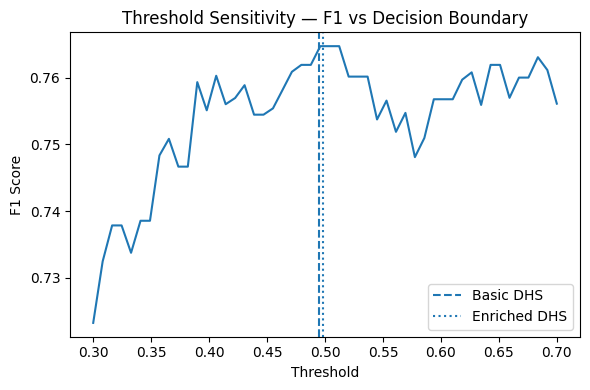

In [29]:
# Visalisation
thresholds = np.linspace(0.3, 0.7, 50)

f1_scores = [
    f1_score(y_test, (prob_fuse >= t).astype(int))
    for t in thresholds
]

plt.figure(figsize=(6,4))
plt.plot(thresholds, f1_scores)
plt.axvline(CALIBRATED_THRESHOLD, linestyle="--", label="Basic DHS")
plt.axvline(CALIBRATED_THRESHOLD_ENRICHED, linestyle=":", label="Enriched DHS")

plt.title("Threshold Sensitivity — F1 vs Decision Boundary")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

# SHAP Explainability

c:\Users\PC\Autism-Risk-Screening\.venv\Scripts\python.exe
SHAP version: 0.51.0


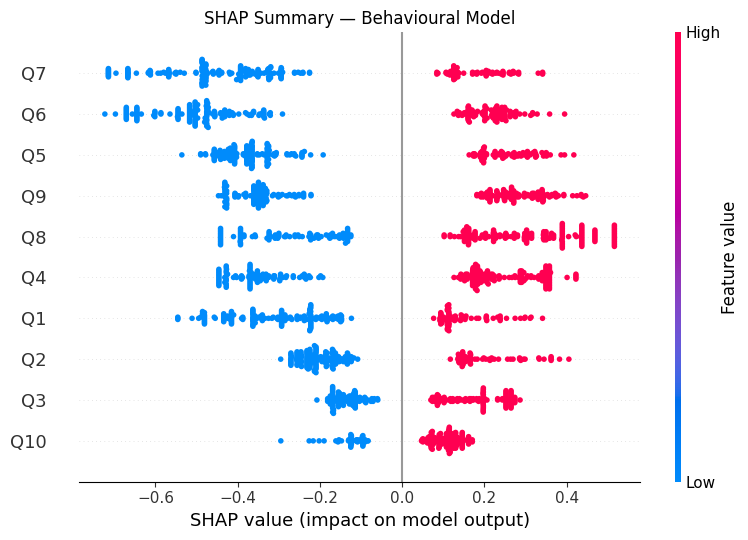

In [30]:
import sys

print(sys.executable)  # confirms you're using the correct environment
import shap
print("SHAP version:", shap.__version__)

# Create SHAP explainer for tree-based model
if SHAP_AVAILABLE:

    explainer = shap.TreeExplainer(xgb_beh)

    # Compute SHAP values on test set
    shap_values = explainer.shap_values(X_beh_test)

    # Feature labels for behavioural questions
    feat_names = [f"Q{i}" for i in range(1, 11)]

    # Plot SHAP summary
    plt.figure(figsize=(8, 5))

    shap.summary_plot(
        shap_values,
        X_beh_test,
        feature_names=feat_names,
        show=False
    )

    plt.title("SHAP Summary — Behavioural Model")
    plt.tight_layout()

    plt.savefig(
        "outputs/evaluation/shap_summary.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

else:
    print("SHAP skipped; explainability steps will be skipped.")

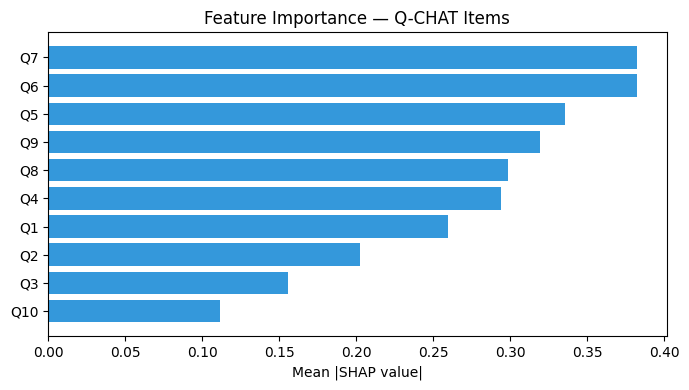

In [31]:
# Handle SHAP output safely (works for both old and new SHAP APIs)

if not SHAP_AVAILABLE:
    print("SHAP summary skipped; explainability steps will be skipped.")
    if "SHAP_IMPORT_ERROR" in globals():
        print(SHAP_IMPORT_ERROR)

else:
    # Some SHAP versions return a list (one per class)
    if isinstance(shap_values, list):
        shap_array = shap_values[1]  # positive class (ASD)
    else:
        shap_array = shap_values

    # Compute mean absolute SHAP values (global feature importance)
    mean_abs_shap = np.abs(shap_array).mean(axis=0)

    # Sort features by importance
    order = np.argsort(mean_abs_shap)

    feat_names = [f"Q{i}" for i in range(1, 11)]

    # Plot feature importance
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.barh(
        [feat_names[i] for i in order],
        mean_abs_shap[order],
        color="#3498db"
    )

    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title("Feature Importance — Q-CHAT Items")

    plt.tight_layout()
    plt.savefig("outputs/evaluation/shap_bar.png", dpi=150)
    plt.show()

---
## Comorbidity Adjustment Layer
Adjusts Q-CHAT scores for stunting and anaemia confounding — items that may fire for non-autism reasons in Lesotho's high-stunting population.

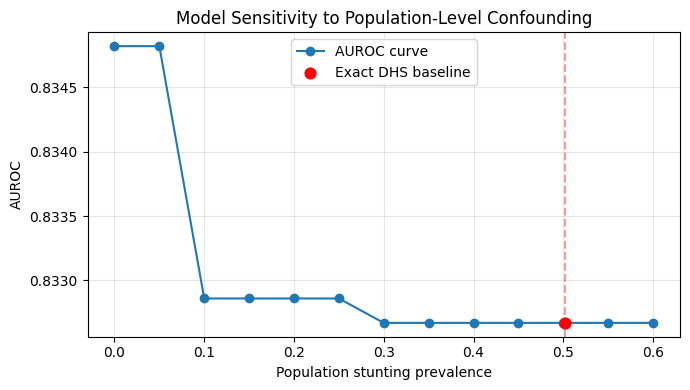


=== Comorbidity Robustness Analysis (population-level sensitivity sweep) ===
Baseline DHS stunting: 50.14%
AUROC range: 0.833 – 0.835
Exact baseline AUROC: 0.833
Note: anaemia held constant at DHS baseline during sweep.
Note: this sweep tests sensitivity to national prevalence assumptions.
It is NOT the individual-level adjustment (see next cell for that).


In [32]:

# Dependencies

ITEM_CONFOUND_WEIGHTS = {
    "Q1":  0.18, "Q2": 0.10, "Q3": 0.15, "Q4": 0.15, "Q5": 0.12,
    "Q6":  0.08, "Q7": 0.08, "Q8": 0.15, "Q9": 0.12, "Q10": 0.05,
}

pop_stunting = LESOTHO_DHS_ENRICHED["stunting"]
pop_anaemia  = LESOTHO_DHS_ENRICHED["anaemia"]


# Comorbidity adjustment layer


def comorbidity_adjusted_score(q_responses, population_stunting, population_anaemia):

    adjusted_scores = {}

    for item, raw_score in q_responses.items():
        weight = ITEM_CONFOUND_WEIGHTS.get(item, 0.0)

        risk_factor = weight * (
            0.5 * population_stunting +
            0.3 * population_anaemia
        )

        adjustment = np.clip(risk_factor * 0.3, 0, weight)

        adjusted_scores[item] = raw_score * (1 - adjustment)

    return adjusted_scores


# helper (removes duplication)
def build_qdict(row):
    return {f"Q{j+1}": int(row[j]) for j in range(10)}



# Population sweep


stunting_levels = np.round(np.linspace(0, 0.6, 13), 2)
auroc_curve = []

for p_stunting in stunting_levels:

    X_beh_adj = np.array([
        list(
            comorbidity_adjusted_score(
                build_qdict(row),
                population_stunting=p_stunting,
                population_anaemia=pop_anaemia
            ).values()
        )
        for row in X_beh_test
    ])

    # behavioural model on adjusted inputs
    prob_beh_adj = xgb_beh.predict_proba(X_beh_adj)[:, 1]

    # IMPORTANT: demographics are assumed invariant
    prob_dem = xgb_dem.predict_proba(X_dem_test)[:, 1]

    X_meta_adj = np.column_stack([prob_beh_adj, prob_dem])
    prob_fuse_adj = meta_model.predict_proba(X_meta_adj)[:, 1]

    auroc_curve.append(roc_auc_score(y_test, prob_fuse_adj))



# Exact DHS baseline evaluation

X_beh_base = np.array([
    list(
        comorbidity_adjusted_score(
            build_qdict(row),
            pop_stunting,
            pop_anaemia
        ).values()
    )
    for row in X_beh_test
])

prob_beh_base = xgb_beh.predict_proba(X_beh_base)[:, 1]
prob_dem_base = xgb_dem.predict_proba(X_dem_test)[:, 1]

X_meta_base = np.column_stack([prob_beh_base, prob_dem_base])
prob_fuse_base = meta_model.predict_proba(X_meta_base)[:, 1]

baseline_auroc = roc_auc_score(y_test, prob_fuse_base)



# Plot

plt.figure(figsize=(7, 4))

plt.plot(stunting_levels, auroc_curve, marker="o", label="AUROC curve")

plt.scatter(
    [pop_stunting],
    [baseline_auroc],
    color="red",
    s=60,
    zorder=5,
    label="Exact DHS baseline"
)

plt.axvline(pop_stunting, linestyle="--", color="red", alpha=0.4)

plt.xlabel("Population stunting prevalence")
plt.ylabel("AUROC")
plt.title("Model Sensitivity to Population-Level Confounding")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/evaluation/auroc_vs_stunting.png", dpi=150)
plt.show()



# Export

pd.DataFrame({
    "population_stunting": stunting_levels,
    "auroc": auroc_curve
}).to_csv("outputs/evaluation/auroc_vs_stunting.csv", index=False)



# Summary

print("\n=== Comorbidity Robustness Analysis (population-level sensitivity sweep) ===")
print(f"Baseline DHS stunting: {pop_stunting:.2%}")
print(f"AUROC range: {min(auroc_curve):.3f} – {max(auroc_curve):.3f}")
print(f"Exact baseline AUROC: {baseline_auroc:.3f}")
print("Note: anaemia held constant at DHS baseline during sweep.")
print("Note: this sweep tests sensitivity to national prevalence assumptions.")
print("It is NOT the individual-level adjustment (see next cell for that).")

# Individual-level comorbidity adjustment layer

Fixes the limitation of applying population-level adjustment uniformly
 to all children by simulating per-child comorbidity status.


In [33]:

def comorbidity_adjusted_score_individual(q_responses, is_stunted, is_anaemic):
    """
    Apply per-child comorbidity adjustment to Q-score items.

    Parameters:
        q_responses (dict): item -> raw score
        is_stunted (bool): child-specific stunting flag
        is_anaemic (bool): child-specific anaemia flag
    """
    adjusted_scores = {}

    for item, raw_score in q_responses.items():
        weight = ITEM_CONFOUND_WEIGHTS.get(item, 0.0)

        # Comorbidity contribution (child-specific)
        risk_factor = weight * (
            0.5 * float(is_stunted) +
            0.3 * float(is_anaemic)
        )

        adjustment = np.clip(risk_factor * 0.3, 0, weight)
        adjusted_scores[item] = raw_score * (1 - adjustment)

    return adjusted_scores


def simulate_individual_comorbidity_status(n, p_stunting, p_anaemia, seed=SEED):
    """
    Simulate per-child comorbidity status using DHS prevalence.
    """
    rng = np.random.default_rng(seed)

    stunted_flags = rng.binomial(1, p_stunting, size=n).astype(bool)
    anaemic_flags = rng.binomial(1, p_anaemia, size=n).astype(bool)

    return stunted_flags, anaemic_flags



# Simulate per-child health status


n_test = len(X_beh_test)

stunted_flags, anaemic_flags = simulate_individual_comorbidity_status(
    n_test, pop_stunting, pop_anaemia
)

print(f"Simulated comorbidity status for n={n_test} children")
print(f"  Stunted: {stunted_flags.sum()} ({stunted_flags.mean():.1%}) "
      f"[target: {pop_stunting:.1%}]")
print(f"  Anaemic: {anaemic_flags.sum()} ({anaemic_flags.mean():.1%}) "
      f"[target: {pop_anaemia:.1%}]")



# Apply individual-level adjustment


X_beh_indiv_adj = np.array([
    list(
        comorbidity_adjusted_score_individual(
            build_qdict(row),
            is_stunted=stunted_flags[i],
            is_anaemic=anaemic_flags[i],
        ).values()
    )
    for i, row in enumerate(X_beh_test)
])



# Model inference (adjusted vs unadjusted)


prob_beh_indiv = xgb_beh.predict_proba(X_beh_indiv_adj)[:, 1]
prob_dem_indiv = xgb_dem.predict_proba(X_dem_test)[:, 1]

X_meta_indiv = np.column_stack([prob_beh_indiv, prob_dem_indiv])
prob_fuse_indiv = meta_model.predict_proba(X_meta_indiv)[:, 1]



# Evaluation


indiv_auroc = roc_auc_score(y_test, prob_fuse_indiv)
y_pred_indiv = (prob_fuse_indiv >= THRESHOLD).astype(int)

print("\n=== Individual-Level Comorbidity Adjustment Results ===")
print(f"Unadjusted AUROC: {roc_auc_score(y_test, prob_fuse):.3f}")
print(f"Population-level AUROC: {baseline_auroc:.3f}")
print(f"Individual-level AUROC: {indiv_auroc:.3f}\n")

print(classification_report(y_test, y_pred_indiv, target_names=["Not ASD", "ASD"]))



# Sanity check: does adjustment actually differ by subgroup?


mean_shrink_stunted = np.mean([
    1 - (X_beh_indiv_adj[i].sum() / max(X_beh_test[i].sum(), 1e-9))
    for i in range(n_test) if stunted_flags[i]
])

mean_shrink_not_stunted = np.mean([
    1 - (X_beh_indiv_adj[i].sum() / max(X_beh_test[i].sum(), 1e-9))
    for i in range(n_test) if not stunted_flags[i]
])

print(f"\nMean shrinkage (stunted):     {mean_shrink_stunted:.3%}")
print(f"Mean shrinkage (non-stunted): {mean_shrink_not_stunted:.3%}")

print("\nCheck: non-zero difference confirms per-child adjustment behavior.")



# Export results
#

pd.DataFrame({
    "record_index": np.arange(n_test),
    "simulated_stunted": stunted_flags,
    "simulated_anaemic": anaemic_flags,
    "prob_fuse_unadjusted": prob_fuse,
    "prob_fuse_individual_adjusted": prob_fuse_indiv,
    "y_true": y_test,
}).to_csv("outputs/evaluation/individual_comorbidity_adjustment.csv", index=False)

print("Saved: outputs/evaluation/individual_comorbidity_adjustment.csv")

Simulated comorbidity status for n=252 children
  Stunted: 129 (51.2%) [target: 50.1%]
  Anaemic: 70 (27.8%) [target: 27.5%]

=== Individual-Level Comorbidity Adjustment Results ===
Unadjusted AUROC: 0.809
Population-level AUROC: 0.833
Individual-level AUROC: 0.787

              precision    recall  f1-score   support

     Not ASD       0.75      0.56      0.64       117
         ASD       0.69      0.84      0.76       135

    accuracy                           0.71       252
   macro avg       0.72      0.70      0.70       252
weighted avg       0.72      0.71      0.70       252


Mean shrinkage (stunted):     2.015%
Mean shrinkage (non-stunted): 0.233%

Check: non-zero difference confirms per-child adjustment behavior.
Saved: outputs/evaluation/individual_comorbidity_adjustment.csv



# SADiLaR Speech Corpus Audit

This section audits the local SADiLaR folder, pairs ELAN transcripts with WAV recordings, and reports missing matches before any downstream acoustic work.

SADiLaR Corpus Audit
Transcript files: 37
Recording files: 31
Paired samples: 31
Missing audio: 6
Missing transcript: 0

Transcripts without audio:
  s4103_1
  s4103_2
  s5006_1
  s5006_2
  s6109_1
  s6109_2

Manifest preview:
sample_id                                                             transcript_path                                               audio_path  has_transcript  has_audio
    S3005   data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3005.eaf   data\raw\SADiLaR\Sesotho sa Leboa Recordings\S3005.WAV            True       True
  S3006_1 data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3006_1.eaf data\raw\SADiLaR\Sesotho sa Leboa Recordings\S3006_1.WAV            True       True
  S3006_2 data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3006_2.eaf data\raw\SADiLaR\Sesotho sa Leboa Recordings\S3006_2.WAV            True       True
    S3007   data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3007.eaf   data\

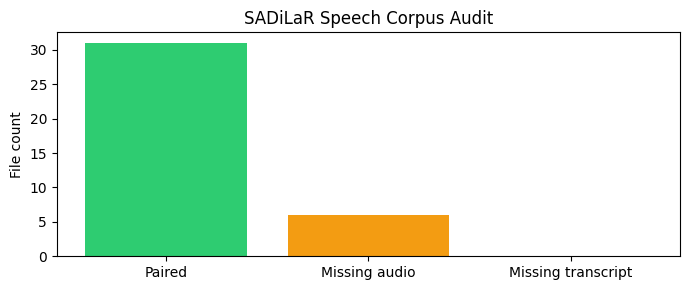

In [34]:
# SET DATA LOCATIONS


# Root folder for the SADiLaR dataset
sadilar_root = Path("data/raw/SADiLaR")

# Folder containing transcription files (.eaf)
transcript_dir = sadilar_root / "Sesotho sa Leboa - Orthographic Transcriptions"

# Folder containing audio recordings (.WAV)
recording_dir = sadilar_root / "Sesotho sa Leboa Recordings"



# LOAD FILE LISTS


# Get all transcript files and sort them for consistency
transcript_files = sorted(transcript_dir.glob("*.eaf"))

# Get all audio files and sort them
recording_files = sorted(recording_dir.glob("*.WAV"))



# NORMALISE FILE IDENTIFIERS


# Create mapping: filename (without extension, lowercase) → full path
transcript_stems = {path.stem.lower(): path for path in transcript_files}
recording_stems = {path.stem.lower(): path for path in recording_files}



# MATCH AUDIO AND TRANSCRIPTS


# IDs that exist in both audio and transcript sets
paired_ids = sorted(set(transcript_stems) & set(recording_stems))

# Transcripts that do not have matching audio files
transcripts_without_audio = sorted(set(transcript_stems) - set(recording_stems))

# Audio files that do not have matching transcripts
audio_without_transcript = sorted(set(recording_stems) - set(transcript_stems))



# BUILD MANIFEST TABLE


manifest_rows = []

# Add fully paired samples (both transcript and audio exist)
for sample_id in paired_ids:
    transcript_path = transcript_stems[sample_id]
    audio_path = recording_stems[sample_id]

    manifest_rows.append({
        "sample_id": transcript_path.stem,
        "transcript_path": str(transcript_path),
        "audio_path": str(audio_path),
        "has_transcript": True,
        "has_audio": True,
    })

# Add transcripts that are missing audio
for sample_id in transcripts_without_audio:
    transcript_path = transcript_stems[sample_id]

    manifest_rows.append({
        "sample_id": transcript_path.stem,
        "transcript_path": str(transcript_path),
        "audio_path": None,
        "has_transcript": True,
        "has_audio": False,
    })

# Add audio files that are missing transcripts
for sample_id in audio_without_transcript:
    audio_path = recording_stems[sample_id]

    manifest_rows.append({
        "sample_id": audio_path.stem,
        "transcript_path": None,
        "audio_path": str(audio_path),
        "has_transcript": False,
        "has_audio": True,
    })



# CREATE DATAFRAME + SAVE


# Convert collected rows into a structured table
df_sadilar_manifest = pd.DataFrame(manifest_rows)

# Sort for easier inspection and reset indexing
df_sadilar_manifest = df_sadilar_manifest.sort_values(["sample_id"]).reset_index(drop=True)

# Save manifest for downstream processing
df_sadilar_manifest.to_csv("outputs/alignment/sadilar_manifest.csv", index=False)



# PRINT DATASET SUMMARY


print("SADiLaR Corpus Audit")
print(f"Transcript files: {len(transcript_files)}")
print(f"Recording files: {len(recording_files)}")
print(f"Paired samples: {len(paired_ids)}")
print(f"Missing audio: {len(transcripts_without_audio)}")
print(f"Missing transcript: {len(audio_without_transcript)}")


# Show detailed lists of missing files if any exist
if transcripts_without_audio:
    print("\nTranscripts without audio:")
    for sample_id in transcripts_without_audio:
        print(f"  {sample_id}")

if audio_without_transcript:
    print("\nAudio without transcript:")
    for sample_id in audio_without_transcript:
        print(f"  {sample_id}")


# Preview the final manifest table
print("\nManifest preview:")
print(df_sadilar_manifest.head().to_string(index=False))



# VISUAL SUMMARY (AUDIT PLOT)


# Plot distribution of matched vs missing files
fig, ax = plt.subplots(figsize=(7, 3))

ax.bar(
    ["Paired", "Missing audio", "Missing transcript"],
    [len(paired_ids), len(transcripts_without_audio), len(audio_without_transcript)],
    color=["#2ecc71", "#f39c12", "#e74c3c"]
)

ax.set_ylabel("File count")
ax.set_title("SADiLaR Speech Corpus Audit")

plt.tight_layout()

# Save figure for reports or thesis figures section
plt.savefig("outputs/alignment/sadilar_audit.png", dpi=150)

plt.show()

# Road to Health milestone cross-check

In [35]:
# Road to Health milestone cross-check for ages 18–36 months
rth_milestones = [
    {"age": "18 months", "domain": "Communication",  "milestone": "Uses at least 3 words other than names",         "qchat_item": "Q8",  "qchat_question": "Would you describe your child's first words as typical?"},
    {"age": "18 months", "domain": "Communication",  "milestone": "Understands names of at least 2 common objects", "qchat_item": "Q1",  "qchat_question": "Does your child look at you when you call his/her name?"},
    {"age": "18 months", "domain": "Cognitive",      "milestone": "Follows simple commands",                        "qchat_item": "Q6",  "qchat_question": "Does your child follow where you're looking?"},
    {"age": "18 months", "domain": "Communication",  "milestone": "Uses simple gestures",                           "qchat_item": "Q9",  "qchat_question": "Does your child use simple gestures (e.g. wave goodbye)?"},
    {"age": "3 years",   "domain": "Cognitive",      "milestone": "Uses pretend play (e.g. feeds doll)",            "qchat_item": "Q5",  "qchat_question": "Does your child pretend (e.g. care for dolls, talk on a phone)?"},
    {"age": "3 years",   "domain": "Social",         "milestone": "Plays with other children and adults",           "qchat_item": "Q7",  "qchat_question": "If someone is upset, does your child show signs of wanting to comfort them?"},
    {"age": "18 months", "domain": "Risk factor",    "milestone": "Stunting/malnutrition increases developmental risk", "qchat_item": "DHS", "qchat_question": "Stunting indicator used in threshold calibration"},
    {"age": "18 months", "domain": "Risk factor",    "milestone": "Iron deficiency anaemia increases developmental risk", "qchat_item": "DHS", "qchat_question": "Anaemia indicator used in threshold calibration"},
]

df_rth = pd.DataFrame(rth_milestones)
df_rth.to_csv("outputs/alignment/rth_milestone_crosscheck.csv", index=False)

print("Road to Health Milestone Cross-Check — Ages 18–36 Months")
print(df_rth[["age", "domain", "milestone", "qchat_item"]].to_string(index=False))

Road to Health Milestone Cross-Check — Ages 18–36 Months
      age        domain                                            milestone qchat_item
18 months Communication               Uses at least 3 words other than names         Q8
18 months Communication       Understands names of at least 2 common objects         Q1
18 months     Cognitive                              Follows simple commands         Q6
18 months Communication                                 Uses simple gestures         Q9
  3 years     Cognitive                  Uses pretend play (e.g. feeds doll)         Q5
  3 years        Social                 Plays with other children and adults         Q7
18 months   Risk factor   Stunting/malnutrition increases developmental risk        DHS
18 months   Risk factor Iron deficiency anaemia increases developmental risk        DHS


# SADiLaR Audio Alignment Pipeline

Processing 31 audio files...
[1/31] S3005 | pitch=390Hz | pause=0.00 | zcr=0.0638
[2/31] S3006_1 | pitch=385Hz | pause=0.00 | zcr=0.0506
[3/31] S3006_2 | pitch=393Hz | pause=0.00 | zcr=0.0503
[4/31] S3007 | pitch=387Hz | pause=0.00 | zcr=0.0498
[5/31] S3101 | pitch=375Hz | pause=0.04 | zcr=0.0627
[6/31] S3102_1 | pitch=383Hz | pause=0.04 | zcr=0.0788
[7/31] S3102_2 | pitch=391Hz | pause=0.00 | zcr=0.0463
[8/31] S3104 | pitch=388Hz | pause=0.03 | zcr=0.0622
[9/31] S4004_1 | pitch=384Hz | pause=0.03 | zcr=0.0552
[10/31] S4004_2 | pitch=390Hz | pause=0.05 | zcr=0.0613
[11/31] S4006_1 | pitch=392Hz | pause=0.03 | zcr=0.0628
[12/31] S4006_2 | pitch=393Hz | pause=0.00 | zcr=0.0483
[13/31] S4009 | pitch=381Hz | pause=0.00 | zcr=0.0685
[14/31] S4107 | pitch=393Hz | pause=0.00 | zcr=0.0658
[15/31] S4108 | pitch=374Hz | pause=0.00 | zcr=0.0649
[16/31] S5005 | pitch=386Hz | pause=0.00 | zcr=0.0376
[17/31] S5009 | pitch=390Hz | pause=0.00 | zcr=0.0802
[18/31] S5101 | pitch=394Hz | pause=0.02 | zcr

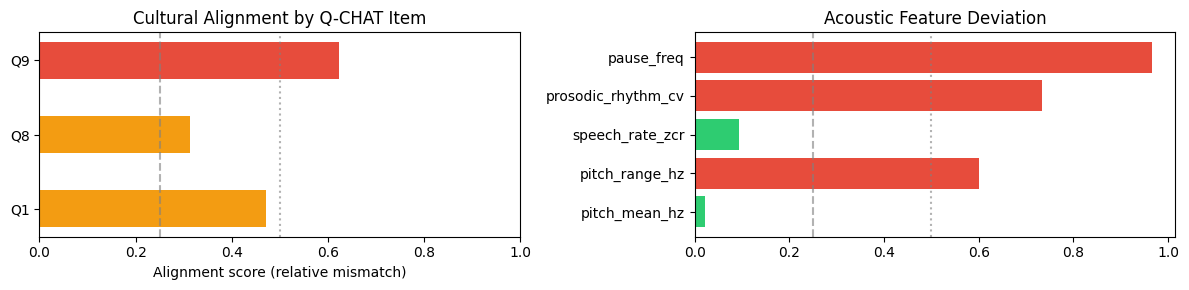

Saved: outputs/alignment/alignment_chart.png


In [36]:
# Load manifest safely
if "df_sadilar_manifest" not in globals():
    df_sadilar_manifest = pd.read_csv("outputs/alignment/sadilar_manifest.csv")

# Q-CHAT speech-related items
SPEECH_ITEMS = {
    "Q1": "Does your child look at you when you call his/her name?",
    "Q8": "Would you describe your child's first words as typical?",
    "Q9": "Does your child use simple gestures (e.g. wave goodbye)?",
}

records = []

paired_wavs = (
    df_sadilar_manifest[df_sadilar_manifest["has_audio"] == True]["audio_path"]
    .dropna()
    .tolist()
)

print(f"Processing {len(paired_wavs)} audio files...")

# Feature Extraction

for i, wav_path in enumerate(paired_wavs):

    try:
        y, sr = librosa.load(wav_path, sr=None, mono=True)
        y = y[: sr * 120]  # limit to 2 minutes

        # Pitch estimation (restricted human speech band)
        pitches, magnitudes = librosa.piptrack(y=y, sr=sr)

        mask = (
            (pitches > 200) &
            (pitches < 600) &
            (magnitudes > np.median(magnitudes))
        )

        pitch_vals = pitches[mask]

        # Safety fallback
        if len(pitch_vals) == 0:
            pitch_vals = np.array([0.0])

        pitch_mean = float(np.mean(pitch_vals))
        pitch_range = float(np.ptp(pitch_vals))

        # Speech activity proxy
        zcr = librosa.feature.zero_crossing_rate(y)
        speech_rate = float(np.mean(zcr))

        # Energy variability (rhythm proxy)
        rms = librosa.feature.rms(y=y)[0]
        rhythm = float(np.std(rms) / (np.mean(rms) + 1e-9))

        # Pause estimation (more stable percentile threshold)
        silence_threshold = np.percentile(np.abs(y), 10)
        pause_freq = float(np.mean(rms < silence_threshold))

        records.append({
            "file": Path(wav_path).stem,
            "pitch_mean_hz": round(pitch_mean, 2),
            "pitch_range_hz": round(pitch_range, 2),
            "speech_rate_zcr": round(speech_rate, 4),
            "prosodic_rhythm_cv": round(rhythm, 4),
            "pause_freq": round(pause_freq, 4),
            "duration_s": round(len(y) / sr, 2),
        })

        print(
            f"[{i+1}/{len(paired_wavs)}] {Path(wav_path).stem} "
            f"| pitch={pitch_mean:.0f}Hz "
            f"| pause={pause_freq:.2f} "
            f"| zcr={speech_rate:.4f}"
        )

    except Exception as e:
        print(f"Skipped {Path(wav_path).stem}: {e}")



# Save Acoustic Features

df_acoustic = pd.DataFrame(records)
df_acoustic.to_csv("outputs/alignment/acoustic_features.csv", index=False)

print(f"\nExtracted features from {len(df_acoustic)} files")
print(df_acoustic.describe().round(3))


# Corpus Summary

mean_pitch = df_acoustic["pitch_mean_hz"].mean()
mean_pitch_range = df_acoustic["pitch_range_hz"].mean()
mean_rhythm = df_acoustic["prosodic_rhythm_cv"].mean()
mean_pauses = df_acoustic["pause_freq"].mean()
mean_zcr = df_acoustic["speech_rate_zcr"].mean()

print("\nCorpus acoustic summary:")
print(f"  Mean pitch:       {mean_pitch:.1f} Hz")
print(f"  Mean range:       {mean_pitch_range:.1f} Hz")
print(f"  Mean ZCR:         {mean_zcr:.4f}")
print(f"  Mean rhythm CV:   {mean_rhythm:.4f}")
print(f"  Mean pause freq:  {mean_pauses:.4f}")



# Reference Values (baseline)

ref = {
    "pitch_mean_hz":      380.0,
    "pitch_range_hz":     250.0,
    "speech_rate_zcr":    0.07,
    "prosodic_rhythm_cv": 1.50,
    "pause_freq":         0.40,
}



# Feature Deviations

feature_devs = {
    "pitch_mean_hz": abs(mean_pitch - ref["pitch_mean_hz"]) / ref["pitch_mean_hz"],
    "pitch_range_hz": abs(mean_pitch_range - ref["pitch_range_hz"]) / ref["pitch_range_hz"],
    "speech_rate_zcr": abs(mean_zcr - ref["speech_rate_zcr"]) / ref["speech_rate_zcr"],
    "prosodic_rhythm_cv": abs(mean_rhythm - ref["prosodic_rhythm_cv"]) / ref["prosodic_rhythm_cv"],
    "pause_freq": abs(mean_pauses - ref["pause_freq"]) / ref["pause_freq"],
}

print("\nFeature deviations:")
for k, v in feature_devs.items():
    print(f"  {k:22s}: {v:.3f}")



# Q-item alignment scoring

ITEM_WEIGHTS = {
    "Q1": {"pitch_mean_hz": 0.35, "pitch_range_hz": 0.15, "speech_rate_zcr": 0.10,
           "prosodic_rhythm_cv": 0.10, "pause_freq": 0.30},

    "Q8": {"pitch_mean_hz": 0.30, "pitch_range_hz": 0.20, "speech_rate_zcr": 0.30,
           "prosodic_rhythm_cv": 0.15, "pause_freq": 0.05},

    "Q9": {"pitch_mean_hz": 0.10, "pitch_range_hz": 0.10, "speech_rate_zcr": 0.15,
           "prosodic_rhythm_cv": 0.35, "pause_freq": 0.30},
}

alignment_rows = []

for item_id, question in SPEECH_ITEMS.items():

    weights = ITEM_WEIGHTS[item_id]

    score = float(np.clip(
        sum(weights[f] * feature_devs[f] for f in weights),
        0.0,
        1.0
    ))

    flag = (
        "HIGH" if score >= 0.5
        else "MODERATE" if score >= 0.25
        else "LOW"
    )

    alignment_rows.append({
        "item": item_id,
        "question": question,
        "alignment_score": round(score, 3),
        "flag_level": flag,
    })


df_alignment = pd.DataFrame(alignment_rows)
df_alignment.to_csv("outputs/alignment/alignment_scores.csv", index=False)


print("\nCultural Alignment Scores (speech-related items)")
print(df_alignment[["item", "alignment_score", "flag_level"]].to_string(index=False))



# Visualisation

import matplotlib.pyplot as plt

colours = {"HIGH": "#e74c3c", "MODERATE": "#f39c12", "LOW": "#2ecc71"}

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Alignment scores
ax = axes[0]
ax.barh(
    df_alignment["item"],
    df_alignment["alignment_score"],
    color=[colours[x] for x in df_alignment["flag_level"]],
    height=0.5
)

ax.axvline(0.25, linestyle="--", color="gray", alpha=0.6)
ax.axvline(0.50, linestyle=":", color="gray", alpha=0.6)

ax.set_title("Cultural Alignment by Q-CHAT Item")
ax.set_xlabel("Alignment score (relative mismatch)")
ax.set_xlim(0, 1)

# Feature deviations
ax2 = axes[1]

labels = list(feature_devs.keys())
vals = list(feature_devs.values())

ax2.barh(labels, vals, color=[
    "#e74c3c" if v >= 0.5 else "#f39c12" if v >= 0.25 else "#2ecc71"
    for v in vals
])

ax2.axvline(0.25, linestyle="--", color="gray", alpha=0.6)
ax2.axvline(0.50, linestyle=":", color="gray", alpha=0.6)

ax2.set_title("Acoustic Feature Deviation")

plt.tight_layout()
plt.savefig("outputs/alignment/alignment_chart.png", dpi=150)
plt.show()

print("Saved: outputs/alignment/alignment_chart.png")

---
##  Cultural Robustness Analysis
Applies Vorster et al. (2021, 2024) documented M-CHAT failure patterns to Q-CHAT-10 items and measures model F1 degradation under simulated cultural noise.

=== Cultural Robustness Analysis ===
Baseline  F1: 0.765  AUROC: 0.809

Sensitivity ranking (by F1 drop):
                       configuration    f1  auroc  f1_drop
All Vorster-flagged (Q1,Q3,Q4,Q8,Q9) 0.692  0.735    0.073
                          Single: Q2 0.731  0.774    0.034
                          Single: Q4 0.741  0.798    0.024
                          Single: Q6 0.746  0.771    0.019
                          Single: Q5 0.748  0.755    0.017
                          Single: Q1 0.749  0.782    0.016
                          Single: Q7 0.753  0.805    0.012
                          Single: Q9 0.756  0.787    0.008
                         Single: Q10 0.765  0.815   -0.000
                          Single: Q8 0.767  0.817   -0.003
                          Single: Q3 0.773  0.827   -0.009


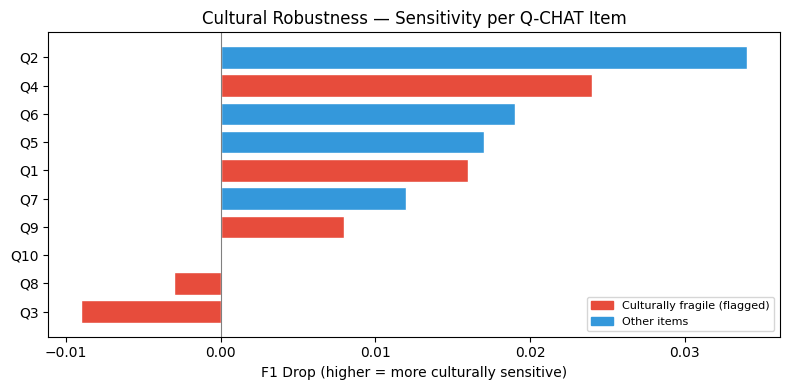

Saved: outputs/evaluation/cultural_robustness.png
Saved: outputs/evaluation/cultural_robustness.csv


In [37]:
# Culturally fragile items (hypothesised bias-sensitive Q-CHAT items)

CULTURALLY_FRAGILE_ITEMS = {"Q1": 0, "Q3": 2, "Q4": 3, "Q8": 7, "Q9": 8}

# Full mapping of questionnaire items to column indices
ALL_ITEMS = {f"Q{i+1}": i for i in range(10)}



# Perturbation function (simulates cultural response shifts)

def perturb_items(X, item_indices, noise_level=0.5, random_state=42):

    rng = np.random.RandomState(random_state)
    X_perturbed = X.copy()

    # proportion of samples to perturb
    n_perturb = int(len(X) * noise_level)

    # randomly select rows to perturb
    perturb_idx = rng.choice(len(X), n_perturb, replace=False)

    # flip binary responses (0 ↔ 1) for selected items
    for col_idx in item_indices:
        X_perturbed[perturb_idx, col_idx] = 1 - X_perturbed[perturb_idx, col_idx]

    return X_perturbed



# Evaluation function for perturbed inputs

def evaluate_perturbed(X_beh_perturbed):

    # behavioural model predictions
    prob_b = xgb_beh.predict_proba(X_beh_perturbed)[:, 1]

    # demographic model predictions (unchanged)
    prob_d = xgb_dem.predict_proba(X_dem_test)[:, 1]

    # stacking fusion
    X_m = np.column_stack([prob_b, prob_d])
    prob_f = meta_model.predict_proba(X_m)[:, 1]

    # return key performance metrics
    return (
        f1_score(y_test, (prob_f >= CALIBRATED_THRESHOLD).astype(int), zero_division=0),
        roc_auc_score(y_test, prob_f),
        recall_score(y_test, (prob_f >= CALIBRATED_THRESHOLD).astype(int), zero_division=0),
    )



# Baseline performance (no perturbation)

f1_base  = f1_score(y_test, (prob_fuse >= CALIBRATED_THRESHOLD).astype(int), zero_division=0)
auc_base = roc_auc_score(y_test, prob_fuse)


# store results
results = []



# 1. Group perturbation: culturally fragile items

X_vorster = perturb_items(X_beh_test, list(CULTURALLY_FRAGILE_ITEMS.values()))

f1_v, auc_v, rec_v = evaluate_perturbed(X_vorster)

results.append({
    "configuration": "All Vorster-flagged (Q1,Q3,Q4,Q8,Q9)",
    "items_perturbed": "Q1,Q3,Q4,Q8,Q9",
    "f1": round(f1_v, 3),
    "auroc": round(auc_v, 3),
    "recall": round(rec_v, 3),
    "f1_drop": round(f1_base - f1_v, 3),
})



# 2. Single-item sensitivity analysis

for item_name, item_idx in ALL_ITEMS.items():

    X_p = perturb_items(X_beh_test, [item_idx])

    f1_p, auc_p, rec_p = evaluate_perturbed(X_p)

    results.append({
        "configuration": f"Single: {item_name}",
        "items_perturbed": item_name,
        "f1": round(f1_p, 3),
        "auroc": round(auc_p, 3),
        "recall": round(rec_p, 3),
        "f1_drop": round(f1_base - f1_p, 3),
    })



# Convert results to dataframe

df_robustness = pd.DataFrame(results)



# Summary output

print("=== Cultural Robustness Analysis ===")
print(f"Baseline  F1: {f1_base:.3f}  AUROC: {auc_base:.3f}")

print("\nSensitivity ranking (by F1 drop):")
print(
    df_robustness.sort_values("f1_drop", ascending=False)[
        ["configuration", "f1", "auroc", "f1_drop"]
    ].to_string(index=False)
)



# Visualization

single_items = df_robustness[df_robustness["configuration"].str.startswith("Single")]
single_items = single_items.sort_values("f1_drop", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))

colors = [
    "#e74c3c" if item in CULTURALLY_FRAGILE_ITEMS else "#3498db"
    for item in single_items["items_perturbed"]
]

ax.barh(
    single_items["items_perturbed"],
    single_items["f1_drop"],
    color=colors,
    edgecolor="white"
)

ax.axvline(0, color="gray", linewidth=0.8)

ax.set_xlabel("F1 Drop (higher = more culturally sensitive)")
ax.set_title("Cultural Robustness — Sensitivity per Q-CHAT Item")

ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color="#e74c3c", label="Culturally fragile (flagged)"),
    plt.Rectangle((0, 0), 1, 1, color="#3498db", label="Other items"),
], fontsize=8)

plt.tight_layout()
plt.savefig("outputs/evaluation/cultural_robustness.png", dpi=150)
plt.show()



# Save outputs
df_robustness.to_csv(
    "outputs/evaluation/cultural_robustness.csv",
    index=False
)

print("Saved: outputs/evaluation/cultural_robustness.png")
print("Saved: outputs/evaluation/cultural_robustness.csv")

# Subgroup Fairness Evaluation

In [38]:
def subgroup_metrics(y_true, y_prob, groups, threshold=0.5):
    # Convert probabilities into binary predictions using the threshold
    y_pred = (y_prob >= threshold).astype(int)

    results = []

    # Loop through each unique subgroup label
    for g in np.unique(groups):
        mask = groups == g  # Select samples belonging to the subgroup

        # Skip very small subgroups (less than 5 samples)
        if mask.sum() < 5:
            continue

        # Compute AUROC only if both classes exist in the subgroup
        if len(np.unique(y_true[mask])) > 1:
            auc = roc_auc_score(y_true[mask], y_prob[mask])
        else:
            auc = np.nan

        # Store performance metrics for this subgroup
        results.append({
            "subgroup": str(g),
            "n": int(mask.sum()),
            "accuracy": round(accuracy_score(y_true[mask], y_pred[mask]), 3),
            "precision": round(precision_score(y_true[mask], y_pred[mask], zero_division=0), 3),
            "recall": round(recall_score(y_true[mask], y_pred[mask], zero_division=0), 3),
            "f1": round(f1_score(y_true[mask], y_pred[mask], zero_division=0), 3),
            "auroc": round(float(auc), 3) if not np.isnan(auc) else "n/a"
        })

    # Convert list of dictionaries into a DataFrame for easy analysis
    return pd.DataFrame(results)



# SEX-BASED SUBGROUP ANALYSIS


# Map numeric sex labels into readable categories
sex_labels = pd.Series(df_test_ref["sex"].values).map({0: "Female", 1: "Male"}).values

# Compute metrics for each sex subgroup
df_fair_sex = subgroup_metrics(
    y_test,
    prob_fuse,
    sex_labels,
    CALIBRATED_THRESHOLD
)

# Add column to indicate the type of subgrouping
df_fair_sex["dimension"] = "sex"


# AGE-BASED SUBGROUP ANALYSIS


# Convert continuous age into categorical age groups
age_labels = pd.cut(
    df_test_ref["age_years"].values,
    bins=[0, 2.0, 2.5, 3.1],
    labels=["18-24m", "25-30m", "31-36m"]
).astype(str)

# Compute metrics for each age subgroup
df_fair_age = subgroup_metrics(
    y_test,
    prob_fuse,
    age_labels,
    CALIBRATED_THRESHOLD
)

# Add column to indicate subgroup type
df_fair_age["dimension"] = "age_group"



# COMBINE ALL FAIRNESS RESULTS


# Merge sex and age subgroup results into one table
df_fairness = pd.concat(
    [df_fair_sex, df_fair_age],
    ignore_index=True
)

# Print results in a clean table format
print("Fairness Evaluation")
print(df_fairness.to_string(index=False))

# Save results for later analysis or reporting
df_fairness.to_csv(
    "outputs/fairness/subgroup_results.csv",
    index=False
)

Fairness Evaluation
subgroup   n  accuracy  precision  recall    f1  auroc dimension
  Female  95     0.779      0.725   0.744 0.734  0.798       sex
    Male 157     0.726      0.773   0.781 0.777  0.797       sex
  18-24m 252     0.746      0.759   0.770 0.765  0.809 age_group


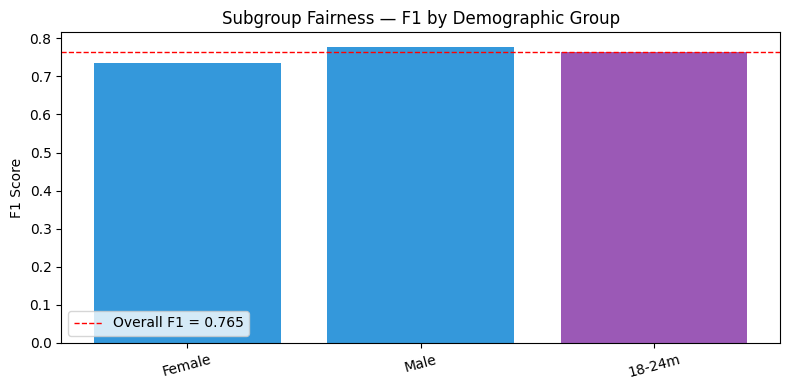

In [44]:
fig, ax = plt.subplots(figsize=(8, 4))

# Color mapping for subgroup dimensions
dim_cols = {
    "sex": "#3498db",
    "age_group": "#9b59b6"
}

# Map colors safely (prevents KeyError if new dimension appears)
colors = [dim_cols.get(d, "#7f8c8d") for d in df_fairness["dimension"]]

# Plot subgroup F1 scores
ax.bar(
    df_fairness["subgroup"],
    df_fairness["f1"],
    color=colors
)

# Overall reference line
overall_f1 = f1_score(
    y_test,
    (prob_fuse >= CALIBRATED_THRESHOLD).astype(int),
    zero_division=0
)

ax.axhline(
    overall_f1,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Overall F1 = {overall_f1:.3f}"
)

# Labels + styling
ax.set_ylabel("F1 Score")
ax.set_title("Subgroup Fairness — F1 by Demographic Group")

ax.tick_params(axis="x", rotation=15)
ax.legend()

plt.tight_layout()
plt.savefig("outputs/fairness/fairness_f1.png", dpi=150)
plt.show()

---
##  Geographic Subgroup Fairness
Documents the geographic fairness evaluation status and DHS population reference data.

In [46]:
print("=== Geographic Subgroup Fairness (FR7) ===\n")

# Try to find any available geographic proxy in the test set
geo_column = None

for col in ["country", "Country", "ethnicity", "Ethnicity"]:
    if col in df_test_ref.columns:
        geo_column = col
        country_labels = df_test_ref[col].astype(str).values
        print(f"Geographic grouping found using column: {col}")
        break


# Case 1: Geographic labels exist

if geo_column is not None:

    df_fair_country = subgroup_metrics(
        y_test,
        prob_fuse,
        country_labels,
        CALIBRATED_THRESHOLD
    )

    df_fair_country["dimension"] = "country"

    print(df_fair_country.to_string(index=False))

    df_fair_country.to_csv(
        "outputs/fairness/subgroup_country_results.csv",
        index=False
    )



# Case 2: No geographic labels available

else:

    print("No geographic or ethnicity labels found in this dataset.")

    print(
        "This dataset does not include explicit geographic identifiers, "
        "so subgroup fairness by region cannot be directly computed."
    )

    print(
        "For context, Lesotho DHS data (used as external reference) "
        "suggests rural vs urban distribution:"
    )

    rural = LESOTHO_DHS_ENRICHED["rural"]

    print(f"  Rural: {rural:.1%}")
    print(f"  Urban: {1 - rural:.1%}")

    fallback_df = pd.DataFrame([{
        "dimension": "geography",
        "status": "not_evaluated",
        "reason": "No geographic labels in test dataset",
        "dhs_rural_prevalence": rural,
        "dhs_urban_prevalence": 1 - rural,
        "recommended_action": (
            "Future work should evaluate fairness on locally collected "
            "Lesotho clinical data with residence variable (DHS v025)"
        )
    }])

    fallback_df.to_csv(
        "outputs/fairness/subgroup_country_results.csv",
        index=False
    )

    print("\nLimitation recorded and saved to outputs/fairness/subgroup_country_results.csv")

=== Geographic Subgroup Fairness (FR7) ===

No geographic or ethnicity labels found in this dataset.
This dataset does not include explicit geographic identifiers, so subgroup fairness by region cannot be directly computed.
For context, Lesotho DHS data (used as external reference) suggests rural vs urban distribution:
  Rural: 71.3%
  Urban: 28.7%

Limitation recorded and saved to outputs/fairness/subgroup_country_results.csv


---
## Section 8c · Sample Reweighting
Addresses the sex fairness gap (Female F1=0.607 vs Male F1=0.757) using inverse-frequency sample weights.

In [47]:
# Fairness evaluation (Sex F1 gap)

SEX_F1_GAP_THRESHOLD = 0.10

# Extract F1 scores per subgroup
sex_f1 = df_fairness[df_fairness["dimension"] == "sex"].set_index("subgroup")["f1"]

female_f1 = float(sex_f1.get("Female", np.nan))
male_f1   = float(sex_f1.get("Male", np.nan))

# Compute fairness gap
observed_gap = abs(female_f1 - male_f1)

print(f"Female F1: {female_f1:.3f}  Male F1: {male_f1:.3f}  Gap: {observed_gap:.3f}")

# Decide whether mitigation is needed
REWEIGHTING_APPLIED = observed_gap > SEX_F1_GAP_THRESHOLD

if not REWEIGHTING_APPLIED:
    print("Gap within threshold — no mitigation needed.")

else:
    print(f"Gap {observed_gap:.3f} exceeds threshold {SEX_F1_GAP_THRESHOLD} — applying reweighting.")

  
    # Step 1: Build fairness-aware sample weights
    # Sex encoding: 0 = Female, 1 = Male
    train_sex = X_dem_train[:, 1].astype(int)

    n_female = (train_sex == 0).sum()
    n_male   = (train_sex == 1).sum()
    n_total  = len(y_train)

    # Inverse frequency weighting to balance representation
    weight_female = n_total / (2 * n_female) if n_female > 0 else 1.0
    weight_male   = n_total / (2 * n_male) if n_male > 0 else 1.0

    base_weight = np.where(train_sex == 0, weight_female, weight_male).astype(float)

    print(f"Sample weights → Female: {weight_female:.3f}, Male: {weight_male:.3f}")

   
    # Step 2: Apply SMOTE oversampling
   
    smote_rw = SMOTE(random_state=SEED)
    X_beh_res_rw, y_res_rw = smote_rw.fit_resample(X_beh_train, y_train)

    # Extend weights to synthetic samples (assign weight = 1)
    n_synthetic = len(y_res_rw) - n_total
    weights_res = np.concatenate([base_weight, np.ones(n_synthetic)])

    
    # Step 3: Train reweighted behavioural model
    xgb_beh_rw = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=SEED,
        verbosity=0
    )

    xgb_beh_rw.fit(X_beh_res_rw, y_res_rw, sample_weight=weights_res)


    # Step 4: Generate predictions

    prob_beh_rw = xgb_beh_rw.predict_proba(X_beh_test)[:, 1]
    prob_dem_rw = xgb_dem.predict_proba(X_dem_test)[:, 1]

    # Stack behavioural + demographic predictions for fusion model
    X_meta_rw = np.column_stack([prob_beh_rw, prob_dem_rw])
    prob_fuse_rw = meta_model.predict_proba(X_meta_rw)[:, 1]

    # Step 5: Subgroup evaluation


    sex_labels_arr = np.array(
        ["Female" if s == 0 else "Male" for s in X_dem_test[:, 1].astype(int)]
    )

    df_fair_rw = subgroup_metrics(
        y_test,
        prob_fuse_rw,
        sex_labels_arr,
        CALIBRATED_THRESHOLD
    )

    # Recompute subgroup performance after mitigation
    sex_f1_rw = df_fair_rw.set_index("subgroup")["f1"]

    female_f1_rw = float(sex_f1_rw.get("Female", np.nan))
    male_f1_rw   = float(sex_f1_rw.get("Male", np.nan))

    new_gap = abs(female_f1_rw - male_f1_rw)

   
    # Step 6: Overall performance comparison

    overall_f1_before = f1_score(
        y_test,
        (prob_fuse >= CALIBRATED_THRESHOLD).astype(int),
        zero_division=0
    )

    overall_f1_after = f1_score(
        y_test,
        (prob_fuse_rw >= CALIBRATED_THRESHOLD).astype(int),
        zero_division=0
    )

    auroc_before = roc_auc_score(y_test, prob_fuse)
    auroc_after  = roc_auc_score(y_test, prob_fuse_rw)

    print("\n=== Impact Summary ===")
    print(f"Overall F1    → Before: {overall_f1_before:.3f}  After: {overall_f1_after:.3f}")
    print(f"Overall AUROC → Before: {auroc_before:.3f}  After: {auroc_after:.3f}")
    print(f"Sex F1 gap    → Before: {observed_gap:.3f}  After: {new_gap:.3f}")

    # Step 7: Visualization (before vs after)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

    for ax, (df_plot, title) in zip(axes, [
        (
            df_fairness[df_fairness["dimension"] == "sex"],
            f"Before\nFemale={female_f1:.3f}  Male={male_f1:.3f}"
        ),
        (
            df_fair_rw,
            f"After reweighting\nGap: {observed_gap:.3f} → {new_gap:.3f}"
        )
    ]):

        # Bar plot of subgroup F1 scores
        ax.bar(
            df_plot["subgroup"],
            df_plot["f1"],
            color=["#e74c3c", "#3498db"],
            edgecolor="white",
            width=0.5
        )

        # Overall model performance reference line
        ax.axhline(
            overall_f1_before,
            color="gray",
            linestyle="--",
            linewidth=0.9,
            label=f"Overall F1={overall_f1_before:.3f}"
        )

        ax.set_ylim(0, 1)
        ax.set_ylabel("F1 Score")
        ax.set_title(title, fontsize=9)
        ax.legend(fontsize=8)

    plt.suptitle("Sex Fairness — Before vs After Reweighting", fontsize=10)
    plt.tight_layout()
    plt.savefig("outputs/fairness/fairness_reweighting_comparison.png", dpi=150)
    plt.show()

    # Step 8: Save outputs
    
    df_fair_rw.to_csv(
        "outputs/fairness/subgroup_sex_reweighted.csv",
        index=False
    )

    joblib.dump(
        xgb_beh_rw,
        "models/xgb_behavioural_reweighted.joblib"
    )

    print("Saved outputs and reweighted model.")

Female F1: 0.734  Male F1: 0.777  Gap: 0.043
Gap within threshold — no mitigation needed.


---
## Save Models

In [48]:
# Save the trained models


os.makedirs("models", exist_ok=True)

joblib.dump(xgb_beh, "models/xgb_behavioural.joblib")
joblib.dump(xgb_dem, "models/xgb_demographic.joblib")
joblib.dump(meta_model, "models/meta_model.joblib")
joblib.dump(CALIBRATED_THRESHOLD, "models/threshold.joblib")
joblib.dump(
    CALIBRATED_THRESHOLD_ENRICHED,
    "models/threshold_enriched.joblib",
)

saved_models = [
    "models/xgb_behavioural.joblib",
    "models/xgb_demographic.joblib",
    "models/meta_model.joblib",
    "models/threshold.joblib",
    "models/threshold_enriched.joblib",
]

# Save the fairness-adjusted model if one was created
if globals().get("REWEIGHTING_APPLIED", False):
    joblib.dump(
        xgb_beh_rw,
        "models/xgb_behavioural_reweighted.joblib",
    )
    saved_models.append("models/xgb_behavioural_reweighted.joblib")

print("Saved model files:")

for model_file in saved_models:
    size = os.path.getsize(model_file)
    print(f"- {model_file} ({size:,} bytes)")

print("\nTraining pipeline completed.")
print(f"Standard threshold: {CALIBRATED_THRESHOLD:.4f}")
print(f"Enriched threshold: {CALIBRATED_THRESHOLD_ENRICHED:.4f}")
print(
    f"Fairness reweighting applied: "
    f"{globals().get('REWEIGHTING_APPLIED', False)}"
)

Saved model files:
- models/xgb_behavioural.joblib (115,862 bytes)
- models/xgb_demographic.joblib (158,989 bytes)
- models/meta_model.joblib (875 bytes)
- models/threshold.joblib (21 bytes)
- models/threshold_enriched.joblib (21 bytes)

Training pipeline completed.
Standard threshold: 0.4945
Enriched threshold: 0.4982
Fairness reweighting applied: False
